In [45]:
from typing import Optional, Tuple  # 添加这行导入语句
import akshare as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import plotly.graph_objects as go
from datetime import datetime
#from plotly.subplots import make_subplots
import statsmodels.formula.api as smf
from itertools import product
from tqdm import tqdm

# 定义函数

## 初始化

In [10]:
def initialize(
    code: str = '600000', 
    pairingcode: Optional[str] = None,
    start_date: str = '20241015',
    end_date: Optional[str] = None, 
    split_ratio: float = 0.7
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """初始化并获取股票数据，分割训练集和测试集
    
    Args:
        code: 主股票代码，如'600000'
        pairingcode: 配对交易股票代码，如'601166'
        start_date: 开始日期，格式'YYYYMMDD'
        end_date: 结束日期，格式'YYYYMMDD'，默认为当前日期
        split_ratio: 训练集分割比例(0-1)
        
    Returns:
        tuple: (完整数据, 训练集, 测试集)
        
    Raises:
        ValueError: 参数无效时抛出
        Exception: 数据获取失败时抛出
    """
    # 参数验证
    if not isinstance(code, str) or not code.isdigit():
        raise ValueError("股票代码必须是数字字符串")
    if pairingcode is not None and (not isinstance(pairingcode, str) or not pairingcode.isdigit()):
        raise ValueError("配对股票代码必须是数字字符串或None")
    if not isinstance(start_date, str) or len(start_date) != 8 or not start_date.isdigit():
        raise ValueError("开始日期格式应为YYYYMMDD")
    if split_ratio <= 0 or split_ratio >= 1:
        raise ValueError("split_ratio必须在0和1之间")

    try:
        # 设置结束日期
        end_date = end_date or datetime.now().strftime("%Y%m%d")
        
        # 获取主股票数据
        print(f"正在获取股票{code}数据...")
        source_data = ak.stock_zh_a_hist(
            symbol=code, period="daily",
            start_date=start_date, end_date=end_date,
            adjust='hfq'
        )
        
        # 数据预处理
        data = pd.DataFrame()
        data['date'] = pd.to_datetime(source_data['日期'])
        data['price'] = source_data['收盘']
        data['volume'] = source_data['成交量']
        data['returns'] = np.log(data['price']/data['price'].shift(1))
        data['returns_cum'] = (data['returns']).cumprod()+1
        
        # 获取配对股票数据
        if pairingcode is not None:
            print(f"正在获取配对股票{pairingcode}数据...")
            source_data2 = ak.stock_zh_a_hist(
                symbol=pairingcode, period="daily",
                start_date=start_date, end_date=end_date,
                adjust='hfq'
            )
            data2 = pd.DataFrame()
            data2['date'] = pd.to_datetime(source_data2['日期'])
            data2['pairing_price'] = source_data2['收盘']
            data2['pairing_returns'] = np.log(data2['pairing_price']/data2['pairing_price'].shift(1))
            data2['pairing_returns_cum'] = (data['returns']).cumprod()+1
            data = pd.merge(data, data2, on='date', how='inner')
        
        # 设置日期索引并清理数据
        data.set_index('date', inplace=True)
        data.dropna(inplace=True)
        
        if len(data) == 0:
            raise ValueError("获取的数据为空，请检查参数")
        
        # 分割训练集和测试集
        split_date = data.index[int(len(data) * split_ratio)]
        train = data.loc[:split_date].copy()
        test = data.loc[split_date:].copy()
        
        print(f"数据初始化完成，总数据量: {len(data)}，训练集: {len(train)}，测试集: {len(test)}")
        return data, train, test
        
    except Exception as e:
        print(f"数据初始化失败: {str(e)}")
        raise

## Moving average

- 策略计算

In [11]:
def ma(
    df: pd.DataFrame,
    short_window: int = 5,
    long_window: int = 10,
    transaction_cost: float = 0.001
) -> pd.DataFrame:
    """增强版移动平均策略
    
    Args:
        df: 包含价格数据的DataFrame
        short_window: 短期均线窗口
        long_window: 长期均线窗口
        transaction_cost: 每次交易成本(比例)
        
    Returns:
        包含策略信号的DataFrame
    """
    df_ma = df.copy()
    
    # 计算移动均线
    df_ma['sma_short'] = df_ma['price'].rolling(short_window).mean()
    df_ma['sma_long'] = df_ma['price'].rolling(long_window).mean()
    
    # 生成交易信号
    df_ma['position'] = np.where(
        df_ma['sma_short'] > df_ma['sma_long'], 1, -1)
    
    # 计算交易次数（信号变化时）
    df_ma['trade'] = df_ma['position'].diff().abs() / 2
    
    # 计算策略收益（考虑交易成本）
    df_ma['strategy'] = (df_ma['position'].shift(1) * df_ma['returns'] - 
                         df_ma['trade'] * transaction_cost)
    
    # 计算累计收益和回撤
    df_ma['cumret'] = df_ma['strategy'].cumsum().apply(np.exp)
    df_ma['cummax'] = df_ma['cumret'].cummax()
    df_ma['drawdown'] = (df_ma['cummax'] - df_ma['cumret']) / df_ma['cummax']
    
    df_ma.dropna(inplace=True)
    return df_ma

- 策略表现

In [12]:
def showma(df):
    df[['price','sma_short','sma_long']].plot(title='sma_short vs sma_long',figsize=(25,10))
    plt.show()

    df['position'].plot(title='Position',figsize=(25,5))
    plt.show()

    buy = df[df['position'] == 1]
    sell = df[df['position'] == -1]
    df['price'].plot(title='price path and MA operate signal', figsize=(25,10))
    plt.scatter(buy.index, buy['price'], color = 'red')
    plt.scatter(sell.index, sell['price'], color = 'green')
    plt.legend()
    plt.show() 

    df[['returns', 'strategy']].cumsum().apply(np.exp)\
        .plot(title='buy and hold strategy vs Moving average strategy', figsize=(10, 6)) 
    plt.show()

    df[['cumret', 'cummax']].plot(figsize=(10, 6))
    plt.show()

    print('Mean Returns:\n', df[['returns', 'strategy']].mean())
    print('Standard Deviations:\n',df[['returns', 'strategy']].std())
    print('Means/Standard Deviation Ratios:',df[['returns', 'strategy']]\
          .mean()/ df[['returns', 'strategy']].std())
    print('MA train drawdown\n', df['drawdown'].max())

In [13]:
def visualize_ma(df_ma: pd.DataFrame, fig_width: int = 1200) -> None:
    """
    完整动态化移动平均策略可视化（基于Plotly）
    包含：
    1. 价格信号与仓位图
    2. 策略收益对比图
    3. 回撤分析图
    
    Args:
        df_ma: 需包含列 ['price', 'position', 'returns', 'strategy_ma', 'cumret_ma', 'cummax_ma']
        fig_width: 图表宽度（高度自动计算）
    """
    
    # 计算动态高度
    base_height = 500
    fig_height = [base_height, base_height, base_height*0.8]
    
    # ========== 图表1：价格信号与仓位 ==========
    fig1 = make_subplots(
        rows=2, cols=1, 
        shared_xaxes=True,
        vertical_spacing=0.05,
        row_heights=[0.7, 0.3]
    )
    
    # 价格曲线
    fig1.add_trace(
        go.Scatter(
            x=df_ma.index, y=df_ma['price'],
            mode='lines', 
            name='价格',
            line=dict(color='#1f77b4', width=1.5),
            hovertemplate="<b>日期</b>: %{x}<br><b>价格</b>: %{y:.2f}<extra></extra>"
        ),
        row=1, col=1
    )
    
    # 买卖信号（添加B/S标记）
    buy_signals = df_ma[df_ma['position'] == 1]
    sell_signals = df_ma[df_ma['position'] == -1]
    
    fig1.add_trace(
        go.Scatter(
            x=buy_signals.index, 
            y=buy_signals['price'],
            mode='markers+text',
            name='买入',
            text="B",
            textposition="top center",
            marker=dict(
                color='rgba(255, 50, 50, 0.9)',
                size=10,
                symbol='triangle-up'
            ),
            hovertemplate="<b>买入信号</b><br>时间: %{x}<br>价格: %{y:.2f}<extra></extra>"
        ),
        row=1, col=1
    )
    
    fig1.add_trace(
        go.Scatter(
            x=sell_signals.index, 
            y=sell_signals['price'],
            mode='markers+text',
            name='卖出',
            text="S",
            textposition="bottom center",
            marker=dict(
                color='rgba(50, 200, 50, 0.9)',
                size=10,
                symbol='triangle-down'
            ),
            hovertemplate="<b>卖出信号</b><br>时间: %{x}<br>价格: %{y:.2f}<extra></extra>"
        ),
        row=1, col=1
    )
    
    # 仓位显示
    fig1.add_trace(
        go.Bar(
            x=df_ma.index, 
            y=df_ma['position'],
            name='仓位',
            marker=dict(
                color=np.where(df_ma['position'] > 0, 'rgba(255,50,50,0.3)', 'rgba(50,200,50,0.3)'),
                line=dict(width=0)
            ),
            hovertemplate="<b>仓位</b>: %{y}<extra></extra>"
        ),
        row=2, col=1
    )
    
    fig1.update_layout(
        title=dict(
            text='<b>移动平均策略信号</b>',
            font=dict(size=20, family="Microsoft YaHei"),
            x=0.5
        ),
        height=fig_height[0],
        width=fig_width,
        hovermode='x unified',
        legend=dict(orientation="h", y=1.02)
    )
    
    # ========== 图表2：策略收益对比 ==========
    fig2 = go.Figure()
    
    # 买入持有策略
    fig2.add_trace(
        go.Scatter(
            x=df_ma.index,
            y=np.exp(df_ma['returns'].cumsum()),
            name='买入持有',
            line=dict(color='#1f77b4', width=2),
            hovertemplate="<b>日期</b>: %{x}<br><b>收益</b>: %{y:.2f}x<extra></extra>"
        )
    )
    
    # 移动平均策略
    fig2.add_trace(
        go.Scatter(
            x=df_ma.index,
            y=np.exp(df_ma['strategy'].cumsum()),
            name='MA策略',
            line=dict(color='#ff7f0e', width=2),
            hovertemplate="<b>日期</b>: %{x}<br><b>收益</b>: %{y:.2f}x<extra></extra>"
        )
    )
    
    fig2.update_layout(
        title=dict(
            text='<b>买入持有策略 vs 移动平均策略</b>',
            font=dict(size=20, family="Microsoft YaHei"),
            x=0.5
        ),
        yaxis_title='累计收益(倍)',
        height=fig_height[1],
        width=fig_width,
        hovermode='x unified',
        legend=dict(orientation="h", y=1.1)
    )
    
    # ========== 图表3：回撤分析 ==========
    fig3 = make_subplots(specs=[[{"secondary_y": True}]])
    
    # 累计收益曲线
    fig3.add_trace(
        go.Scatter(
            x=df_ma.index,
            y=df_ma['cumret'],
            name='累计收益',
            line=dict(color='#1f77b4', width=2),
            hovertemplate="<b>日期</b>: %{x}<br><b>净值</b>: %{y:.2f}<extra></extra>"
        ),
        secondary_y=False
    )
    
    # 历史峰值曲线
    fig3.add_trace(
        go.Scatter(
            x=df_ma.index,
            y=df_ma['cummax'],
            name='历史峰值',
            line=dict(color='#d62728', width=1.5, dash='dot'),
            hovertemplate="<b>日期</b>: %{x}<br><b>峰值</b>: %{y:.2f}<extra></extra>"
        ),
        secondary_y=False
    )
    
    # 回撤率柱状图
    drawdown = (df_ma['cumret'] / df_ma['cummax'] - 1)
    fig3.add_trace(
        go.Bar(
            x=df_ma.index,
            y=drawdown,
            name='回撤率',
            marker=dict(
                color=np.where(drawdown < 0, 'rgba(200,50,50,0.3)', 'rgba(50,200,50,0.3)'),
                line=dict(width=0)
            ),
            hovertemplate="<b>回撤率</b>: %{y:.2%}<extra></extra>"
        ),
        secondary_y=True
    )
    
    fig3.update_layout(
        title=dict(
            text='<b>累计收益与最大回撤</b>',
            font=dict(size=20, family="Microsoft YaHei"),
            x=0.5
        ),
        height=fig_height[2],
        width=fig_width,
        hovermode='x unified',
        legend=dict(orientation="h", y=1.15)
    )
    
    fig3.update_yaxes(
        title_text="净值",
        secondary_y=False
    )
    fig3.update_yaxes(
        title_text="回撤率",
        tickformat=".0%",
        secondary_y=True
    )
    
    # ========== 显示图表 ==========
    fig1.show()
    fig2.show()
    fig3.show()

    # 可选：返回图表对象
    # return fig1, fig2, fig3

In [14]:
def evaluate_strategy(
    df: pd.DataFrame,
    strategy_col: str = 'strategy'
) -> dict:
    """评估策略表现
    
    Args:
        df: 包含原始收益和策略收益的DataFrame
        strategy_col: 策略收益列名
        
    Returns:
        包含各项评估指标的字典
    """
    if strategy_col not in df.columns:
        raise ValueError(f"DataFrame中不存在策略列'{strategy_col}'")
    
    # 计算基本指标
    returns = df[['returns', strategy_col]]
    metrics = {
        '总收益率': returns.apply(lambda x: np.exp(x.sum()) - 1),
        '年化收益率': returns.apply(lambda x: np.exp(x.mean() * 252) - 1),
        '年化波动率': returns.apply(lambda x: x.std() * np.sqrt(252)),
        '最大回撤': df['drawdown'].max(),
        '交易次数': df['trade'].sum() if 'trade' in df.columns else None
    }
    
    # 计算夏普比率
    metrics['夏普比率'] = metrics['年化收益率'] / metrics['年化波动率']
    
    # 计算胜率
    metrics['胜率'] = returns.apply(lambda x: (x > 0).mean())
    
    return metrics

## Momentum

- 策略计算

In [16]:
def mom(
    df: pd.DataFrame,
    window: int = 10,
    transaction_cost: float = 0.001
) -> pd.DataFrame:
    """动量策略
    
    Args:
        df: 包含价格数据的DataFrame
        window: 动量计算窗口
        transaction_cost: 每次交易成本(比例)
        
    Returns:
        包含策略信号的DataFrame
    """
    df_mom = df.copy()
    
    # 计算动量信号
    df_mom['position'] = np.where(df_mom['returns'].rolling(window).mean() > 0, 1, -1)
    
    # 计算交易次数（信号变化时）
    df_mom['trade'] = df_mom['position'].diff().abs() / 2
    
    # 计算策略收益（考虑交易成本）
    df_mom['strategy'] = (df_mom['position'].shift(1) * df_mom['returns'] - df_mom['trade'] * transaction_cost)
    
    # 计算累计收益和回撤
    df_mom['cumret'] = df_mom['strategy'].cumsum().apply(np.exp)
    df_mom['cummax'] = df_mom['cumret'].cummax()
    df_mom['drawdown'] = (df_mom['cummax'] - df_mom['cumret']) / df_mom['cummax']
    
    df_mom.dropna(inplace=True)
    return df_mom

- 策略表现

In [17]:
def mom_scan(df: pd.DataFrame, fig_width: int = 1200) -> None:
    mom_scans = df.copy()
    mom_scans['std_dev'] = mom_scans['returns_cum'].std()

    price_plot = ['returns_cum']  # 初始化价格图列表
    sharp_plot = ['std_dev']
    for days in range(1, 23):
        price_plot.append('sty_cumr_%dd'%days)
        sharp_plot.append('sharp_%dd'%days)
        # 计算每个时间窗口的动量策略累计收益
        mom_scans['position_%dd'%days]=np.where(mom_scans['returns'].rolling(days).mean()>0,1,-1)
        mom_scans['strategy_%dd'%days]=mom_scans['position_%dd'%days].shift(1)*mom_scans['returns']
        mom_scans['sty_cumr_%dd'%days]=(mom_scans['strategy_%dd'%days]+1).cumprod()
        mom_scans[f'sharp_{days}d'] = mom_scans[f'sty_cumr_{days}d'] / mom_scans[f'sty_cumr_{days}d'].std()

    base_height = 500
    fig_height = [base_height, base_height, base_height*0.8]

    # ========== 图表1：价格信号与仓位 ==========
    fig = make_subplots(
        rows=2, cols=1, 
        shared_xaxes=True,
        vertical_spacing=0.05,
        row_heights= fig_height                                
    )

    for column in price_plot:
        fig.add_trace(
            go.Scatter(
                x=mom_scans.index,
                y=mom_scans[column],
                mode='lines',
                name=column
            )
        )

    # 设置图表布局
    fig.update_layout(
        title=dict(
            text='<b>Cumulative Returns of Different Momentum Strategies</b>',
            font=dict(size=20, family="Microsoft YaHei"),
            x=0.5
        ),
        xaxis_title='Date',
        yaxis_title='Cumulative Returns',
        height=600,
        width=fig_width,
        hovermode='x unified',
        legend=dict(orientation="v", y=1)
    )

    # 显示图表
    fig.show()

    # ========== 图表2：夏普比率 ==========
    fig1 = make_subplots(
        rows=2, cols=1, 
        shared_xaxes=True,
        vertical_spacing=0.05,
        row_heights=[0.7, 0.3]
    )

    for column in sharp_plot:
        fig1.add_trace(
            go.Scatter(
                x=mom_scans.index,
                y=mom_scans[column],
                mode='lines',
                name=column
            )
        )

    # 设置图表布局
    fig1.update_layout(
        title=dict(
            text='<b>Sharpe Ratio of Different Momentum Strategies</b>',
            font=dict(size=20, family="Microsoft YaHei"),
            x=0.5
        ),
        xaxis_title='Date',
        yaxis_title='Sharpe Ratio',
        height=600,
        width=fig_width,
        hovermode='x unified',
        legend=dict(orientation="v", y=1)
    )

    # 显示图表
    fig1.show()

In [18]:
def showmom(df):
    # 收集所有要绘制的列
    cols_to_plot = []
    
    if 'returns_cum' in df.columns:
        cols_to_plot.append('returns_cum')
    
    for days in range(1, 23):
        col_name = 'sty_cumr_%dd' % days
        if col_name in df.columns:
            cols_to_plot.append(col_name)
    
    # 使用pandas绘图
    if cols_to_plot:
        df[cols_to_plot].dropna().plot(figsize=(20, 12),
                                     title='Cumulative Returns of Different Momentum Strategies')
        plt.legend(loc='upper left', ncol=4)
        plt.show()

    # 绘制主要动量策略的信号
    df['position'].plot(title='Position', figsize=(25, 5))
    plt.show()

    # 绘制价格路径和交易信号
    buy = df[df['position'] == 1]
    sell = df[df['position'] == -1]
    df['price'].plot(title='Price Path and Momentum Operation Signal', figsize=(25, 10))
    plt.scatter(buy.index, buy['price'], color='red', label='Buy Signal')
    plt.scatter(sell.index, sell['price'], color='green', label='Sell Signal')
    plt.legend()
    plt.show()

    # 绘制主要动量策略的累计收益对比
    df[['returns', 'strategy']].cumsum().apply(np.exp).plot(title='Buy and Hold vs Momentum Strategy', figsize=(10, 6))
    plt.show()

    # 绘制主要动量策略的累计收益和最大回撤
    df[['cumret', 'cummax']].plot(title='Cumulative Returns and Max Drawdown', figsize=(10, 6))
    plt.show()

    # 打印统计信息
    print('Mean Returns:\n', df[['returns', 'strategy']].mean())
    print('Standard Deviations:\n', df[['returns', 'strategy']].std())
    print('Means/Standard Deviation Ratios:', df[['returns', 'strategy']].mean() / df[['returns', 'strategy']].std())
    print('Momentum train drawdown\n', df['drawdown'].max())

In [19]:
def visualize_mom(df_mom: pd.DataFrame, fig_width: int = 1200) -> None:
    """
    完整动态化移动平均策略可视化（基于Plotly）
    包含：
    1. 价格信号与仓位图
    2. 策略收益对比图
    3. 回撤分析图
    
    Args:
        df_ma: 需包含列 ['price', 'position', 'returns', 'strategy_ma', 'cumret_ma', 'cummax_ma']
        fig_width: 图表宽度（高度自动计算）
    """
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    import numpy as np
    
    # 计算动态高度
    base_height = 500
    fig_height = [base_height, base_height, base_height*0.8]
    
    # ========== 图表1：价格信号与仓位 ==========
    fig1 = make_subplots(
        rows=2, cols=1, 
        shared_xaxes=True,
        vertical_spacing=0.05,
        row_heights=[0.7, 0.3]
    )
    
    # 价格曲线
    fig1.add_trace(
        go.Scatter(
            x=df_mom.index, y=df_mom['price'],
            mode='lines', 
            name='价格',
            line=dict(color='#1f77b4', width=1.5),
            hovertemplate="<b>日期</b>: %{x}<br><b>价格</b>: %{y:.2f}<extra></extra>"
        ),
        row=1, col=1
    )
    
    # 买卖信号（添加B/S标记）
    buy_signals = df_mom[df_mom['position'] == 1]
    sell_signals = df_mom[df_mom['position'] == -1]
    
    fig1.add_trace(
        go.Scatter(
            x=buy_signals.index, 
            y=buy_signals['price'],
            mode='markers+text',
            name='买入',
            text="B",
            textposition="top center",
            marker=dict(
                color='rgba(255, 50, 50, 0.9)',
                size=10,
                symbol='triangle-up'
            ),
            hovertemplate="<b>买入信号</b><br>时间: %{x}<br>价格: %{y:.2f}<extra></extra>"
        ),
        row=1, col=1
    )
    
    fig1.add_trace(
        go.Scatter(
            x=sell_signals.index, 
            y=sell_signals['price'],
            mode='markers+text',
            name='卖出',
            text="S",
            textposition="bottom center",
            marker=dict(
                color='rgba(50, 200, 50, 0.9)',
                size=10,
                symbol='triangle-down'
            ),
            hovertemplate="<b>卖出信号</b><br>时间: %{x}<br>价格: %{y:.2f}<extra></extra>"
        ),
        row=1, col=1
    )
    
    # 仓位显示
    fig1.add_trace(
        go.Bar(
            x=df_mom.index, 
            y=df_mom['position'],
            name='仓位',
            marker=dict(
                color=np.where(df_mom['position'] > 0, 'rgba(255,50,50,0.3)', 'rgba(50,200,50,0.3)'),
                line=dict(width=0)
            ),
            hovertemplate="<b>仓位</b>: %{y}<extra></extra>"
        ),
        row=2, col=1
    )
    
    fig1.update_layout(
        title=dict(
            text='<b>移动平均策略信号</b>',
            font=dict(size=20, family="Microsoft YaHei"),
            x=0.5
        ),
        height=fig_height[0],
        width=fig_width,
        hovermode='x unified',
        legend=dict(orientation="h", y=1.02)
    )
    
    # ========== 图表2：策略收益对比 ==========
    fig2 = go.Figure()
    
    # 买入持有策略
    fig2.add_trace(
        go.Scatter(
            x=df_mom.index,
            y=np.exp(df_mom['returns'].cumsum()),
            name='买入持有',
            line=dict(color='#1f77b4', width=2),
            hovertemplate="<b>日期</b>: %{x}<br><b>收益</b>: %{y:.2f}x<extra></extra>"
        )
    )
    
    # 移动平均策略
    fig2.add_trace(
        go.Scatter(
            x=df_mom.index,
            y=np.exp(df_mom['strategy'].cumsum()),
            name='MOM策略',
            line=dict(color='#ff7f0e', width=2),
            hovertemplate="<b>日期</b>: %{x}<br><b>收益</b>: %{y:.2f}x<extra></extra>"
        )
    )
    
    fig2.update_layout(
        title=dict(
            text='<b>买入持有策略 vs 移动平均策略</b>',
            font=dict(size=20, family="Microsoft YaHei"),
            x=0.5
        ),
        yaxis_title='累计收益(倍)',
        height=fig_height[1],
        width=fig_width,
        hovermode='x unified',
        legend=dict(orientation="h", y=1.1)
    )
    
    # ========== 图表3：回撤分析 ==========
    fig3 = make_subplots(specs=[[{"secondary_y": True}]])
    
    # 累计收益曲线
    fig3.add_trace(
        go.Scatter(
            x=df_mom.index,
            y=df_mom['cumret'],
            name='累计收益',
            line=dict(color='#1f77b4', width=2),
            hovertemplate="<b>日期</b>: %{x}<br><b>净值</b>: %{y:.2f}<extra></extra>"
        ),
        secondary_y=False
    )
    
    # 历史峰值曲线
    fig3.add_trace(
        go.Scatter(
            x=df_mom.index,
            y=df_mom['cummax'],
            name='历史峰值',
            line=dict(color='#d62728', width=1.5, dash='dot'),
            hovertemplate="<b>日期</b>: %{x}<br><b>峰值</b>: %{y:.2f}<extra></extra>"
        ),
        secondary_y=False
    )
    
    # 回撤率柱状图
    drawdown = (df_mom['cumret'] / df_mom['cummax'] - 1)
    fig3.add_trace(
        go.Bar(
            x=df_mom.index,
            y=drawdown,
            name='回撤率',
            marker=dict(
                color=np.where(drawdown < 0, 'rgba(200,50,50,0.3)', 'rgba(50,200,50,0.3)'),
                line=dict(width=0)
            ),
            hovertemplate="<b>回撤率</b>: %{y:.2%}<extra></extra>"
        ),
        secondary_y=True
    )
    
    fig3.update_layout(
        title=dict(
            text='<b>累计收益与最大回撤</b>',
            font=dict(size=20, family="Microsoft YaHei"),
            x=0.5
        ),
        height=fig_height[2],
        width=fig_width,
        hovermode='x unified',
        legend=dict(orientation="h", y=1.15)
    )
    
    fig3.update_yaxes(
        title_text="净值",
        secondary_y=False
    )
    fig3.update_yaxes(
        title_text="回撤率",
        tickformat=".0%",
        secondary_y=True
    )
    
    # ========== 显示图表 ==========
    fig1.show()
    fig2.show()
    fig3.show()

    # 可选：返回图表对象
    # return fig1, fig2, fig3

## Mean_reversion

- 策略计算

In [21]:
def mr(
    df: pd.DataFrame,
    sma_window: int = 15,
    threshold: float = 1.96,
    transaction_cost: float = 0.001
) -> pd.DataFrame:
    """均值回归策略
    
    Args:
        df: 包含价格数据的DataFrame
        sma_window: 移动平均窗口
        threshold: 触发交易的阈值
        transaction_cost: 每次交易成本(比例)
        
    Returns:
        包含策略信号的DataFrame
    """
    df_mr = df.copy()
    
    # 计算移动平均和偏离度
    df_mr['sma'] = df_mr['price'].rolling(sma_window).mean()
    df_mr['distance'] = df_mr['price'] - df_mr['sma']
    
    # 生成交易信号
    df_mr['position'] = np.where(
        df_mr['distance'] > threshold, -1,
        np.where(df_mr['distance'] < -threshold, 1, 0))
    
    # 计算交易次数（信号变化时）
    df_mr['trade'] = df_mr['position'].diff().abs() / 2
    
    # 计算策略收益（考虑交易成本）
    df_mr['strategy'] = (df_mr['position'].shift(1) * df_mr['returns'] - 
                        df_mr['trade'] * transaction_cost)
    
    # 计算累计收益和回撤
    df_mr['cumret'] = df_mr['strategy'].cumsum().apply(np.exp)
    df_mr['cummax'] = df_mr['cumret'].cummax()
    df_mr['drawdown'] = (df_mr['cummax'] - df_mr['cumret']) / df_mr['cummax']
    
    df_mr.dropna(inplace=True)
    return df_mr

- 策略表现

In [22]:
def showmr(df, threshold=1.96):
    df[['price', 'sma']].plot(title='Price vs SMA', figsize=(25, 10))
    plt.show()

    df['distance'].plot(title='Distance', figsize=(25, 10))
    plt.axhline(threshold, color='r', linestyle='--', label=f'Threshold ({threshold})')
    plt.axhline(-threshold, color='r', linestyle='--', label=f'-Threshold ({-threshold})')
    plt.axhline(0, color='black', linestyle='-', linewidth=0.8, label='Zero Line')
    plt.legend()
    plt.show()


    buy = df[df['position'] == 1]
    sell = df[df['position'] == -1]
    df['price'].plot(title='price path and Mean Reversion operate signal', figsize=(25, 10))
    plt.scatter(buy.index, buy['price'], color='red')
    plt.scatter(sell.index, sell['price'], color='green')
    plt.legend()
    plt.show()

    df[['returns', 'strategy']].cumsum().apply(np.exp)\
        .plot(title='buy and hold strategy vs Mean Reversion strategy', figsize=(10, 6))
    plt.show()

    df[['cumret', 'cummax']].plot(figsize=(10, 6))
    plt.show()

    print('Mean Returns:\n', df[['returns', 'strategy']].mean())
    print('Standard Deviations:\n', df[['returns', 'strategy']].std())
    print('Means/Standard Deviation Ratios:', df[['returns', 'strategy']]\
          .mean() / df[['returns', 'strategy']].std())
    print('Mean Reversion train drawdown\n', df['drawdown'].max())

## Pair-trading

- 策略计算

In [24]:
def pt(
    df: pd.DataFrame,
    threshold: float = 1.96,
    low_zscore: float = 0.5,
    transaction_cost: float = 0.001
) -> pd.DataFrame:
    """配对交易策略
    
    Args:
        df: 包含配对价格数据的DataFrame
        threshold: 触发交易的阈值
        low_zscore: 平仓阈值
        transaction_cost: 每次交易成本(比例)
        
    Returns:
        包含策略信号的DataFrame
    """
    df_pt = df.copy()
    
    # 计算价差和Z分数
    df_pt['spread'] = df_pt['price'] - df_pt['pairing_price']
    df_pt['zscore'] = (df_pt['spread'] - df_pt['spread'].mean()) / df_pt['spread'].std()
    
    # 生成交易信号
    df_pt['position_target'] = np.where(
        df_pt['zscore'] > threshold, -1,
        np.where(df_pt['zscore'] < -threshold, 1, 
                np.where(abs(df_pt['zscore']) < low_zscore, 0, np.nan)))
    df_pt['position_target'] = df_pt['position_target'].fillna(method='ffill').fillna(0)
    df_pt['position_pair'] = -df_pt['position_target']
    
    # 计算组合收益和交易次数
    df_pt['strategy_returns'] = (df_pt['position_target'].shift(1) * df_pt['returns'] + 
                               df_pt['position_pair'].shift(1) * df_pt['pairing_returns'])
    df_pt['trade'] = df_pt['position_target'].diff().abs() / 2
    
    # 计算策略收益（考虑交易成本）
    df_pt['strategy'] = df_pt['strategy_returns'] - df_pt['trade'] * transaction_cost
    
    # 计算累计收益和回撤
    df_pt['cumret'] = df_pt['strategy'].cumsum().apply(np.exp)
    df_pt['cummax'] = df_pt['cumret'].cummax()
    df_pt['drawdown'] = (df_pt['cummax'] - df_pt['cumret']) / df_pt['cummax']
    
    df_pt.dropna(inplace=True)
    return df_pt

- 策略表现

In [25]:
def showpt(df, low_zscore=0.5, threshold=1.96):
    df[['price', 'pairing_price', 'spread']].plot(title='Price vs Pairing Price and Spread', figsize=(25, 10))
    plt.show()

    df['zscore'].plot(title='Z-score of Spread', figsize=(25, 5))
    plt.axhline(threshold, color='r', linestyle='--')
    plt.axhline(-threshold, color='r', linestyle='--')
    plt.axhline(low_zscore, color='g', linestyle='--')
    plt.axhline(-low_zscore, color='g', linestyle='--')
    plt.show()

    df['position_target'].plot(title='Position_target', figsize=(25, 5))
    plt.show()

    df['position_pair'].plot(title='Position_pair', figsize=(25, 5))
    plt.show()

    df[['returns', 'strategy']].cumsum().apply(np.exp)\
        .plot(title='buy and hold strategy vs Pair Trading strategy', figsize=(10, 6))
    plt.show()

    df[['cumret', 'cummax']].plot(figsize=(10, 6))
    plt.show()

    print('Mean Returns:\n', df[['returns', 'strategy']].mean())
    print('Standard Deviations:\n', df[['returns', 'strategy']].std())
    print('Means/Standard Deviation Ratios:', df[['returns', 'strategy']]\
          .mean() / df[['returns', 'strategy']].std())
    print('Pair Trading train drawdown\n', df['drawdown'].max())

## 参数优化

## Moving Average

In [ ]:
def optimize_ma(df, short_windows, long_windows, transaction_cost=0.001):
    best_sharpe = -np.inf
    best_params = None
    results = []

    # 生成所有可能的参数组合
    param_combinations = product(short_windows, long_windows)

    for short_window, long_window in param_combinations:
        if short_window >= long_window:
            continue

        # 运行策略
        df_ma = ma(df, short_window, long_window, transaction_cost)

        # 计算夏普比率
        strategy_returns = df_ma['strategy']
        sharpe_ratio = strategy_returns.mean() / strategy_returns.std()

        # 计算最大回撤
        max_drawdown = df_ma['drawdown'].max()

        results.append({
            'short_window': short_window,
            'long_window': long_window,
            'sharpe_ratio': sharpe_ratio,
            'max_drawdown': max_drawdown
        })

        if sharpe_ratio > best_sharpe:
            best_sharpe = sharpe_ratio
            best_params = (short_window, long_window)

    # 输出最佳参数
    print(f"最佳短期窗口: {best_params[0]}, 最佳长期窗口: {best_params[1]}, 最佳夏普比率: {best_sharpe:.4f}")

    # 可视化结果
    results_df = pd.DataFrame(results)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(results_df['short_window'], results_df['sharpe_ratio'], c=results_df['long_window'], cmap='viridis')
    plt.colorbar(label='长期窗口')
    plt.xlabel('短期窗口')
    plt.ylabel('夏普比率')
    plt.title('不同参数组合下的夏普比率')

    plt.subplot(1, 2, 2)
    plt.scatter(results_df['short_window'], results_df['max_drawdown'], c=results_df['long_window'], cmap='viridis')
    plt.colorbar(label='长期窗口')
    plt.xlabel('短期窗口')
    plt.ylabel('最大回撤')
    plt.title('不同参数组合下的最大回撤')

    plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
    plt.tight_layout()
    plt.show()

    return best_params

## Momentum

In [42]:
def optimize_mom(df, windows, transaction_cost=0.001):
    best_sharpe = -np.inf
    best_params = None
    results = []

    for window in windows:
        # 运行策略
        df_mom = mom(df, window, transaction_cost)

        # 计算夏普比率
        strategy_returns = df_mom['strategy']
        sharpe_ratio = strategy_returns.mean() / strategy_returns.std()

        # 计算最大回撤
        max_drawdown = df_mom['drawdown'].max()

        results.append({
            'window': window,
            'sharpe_ratio': sharpe_ratio,
            'max_drawdown': max_drawdown
        })

        if sharpe_ratio > best_sharpe:
            best_sharpe = sharpe_ratio
            best_params = window

    # 输出最佳参数
    print(f"最佳动量计算窗口: {best_params}, 最佳夏普比率: {best_sharpe:.4f}")

    # 可视化结果
    results_df = pd.DataFrame(results)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(results_df['window'], results_df['sharpe_ratio'])
    plt.xlabel('动量计算窗口')
    plt.ylabel('夏普比率')
    plt.title('不同窗口下的夏普比率')

    plt.subplot(1, 2, 2)
    plt.scatter(results_df['window'], results_df['max_drawdown'])
    plt.xlabel('动量计算窗口')
    plt.ylabel('最大回撤')
    plt.title('不同窗口下的最大回撤')

    plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
    plt.tight_layout()
    plt.show()

    return best_params

## Mean_Reversion

In [43]:
def optimize_mr(df, sma_windows, thresholds, transaction_cost=0.001):
    best_sharpe = -np.inf
    best_params = None
    results = []

    param_combinations = product(sma_windows, thresholds)
    total_combinations = len(sma_windows) * len(thresholds)
    pbar = tqdm(total=total_combinations, desc="均值回归策略参数优化")

    for sma_window, threshold in param_combinations:
        # 运行策略
        df_mr = mr(df, sma_window, threshold, transaction_cost)

        # 计算夏普比率
        strategy_returns = df_mr['strategy']
        if strategy_returns.std() == 0:
            sharpe_ratio = 0
        else:
            sharpe_ratio = strategy_returns.mean() / strategy_returns.std()

        # 计算最大回撤
        max_drawdown = df_mr['drawdown'].max()

        results.append({
            'sma_window': sma_window,
            'threshold': threshold,
            'sharpe_ratio': sharpe_ratio,
            'max_drawdown': max_drawdown
        })

        if sharpe_ratio > best_sharpe:
            best_sharpe = sharpe_ratio
            best_params = (sma_window, threshold)

        pbar.update(1)

    pbar.close()

    # 输出最佳参数
    print(f"最佳移动平均窗口: {best_params[0]}, 最佳触发阈值: {best_params[1]}, 最佳夏普比率: {best_sharpe:.4f}")

    # 可视化结果
    results_df = pd.DataFrame(results)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(results_df['sma_window'], results_df['sharpe_ratio'], c=results_df['threshold'], cmap='viridis')
    plt.colorbar(label='触发阈值')
    plt.xlabel('移动平均窗口')
    plt.ylabel('夏普比率')
    plt.title('不同参数组合下的夏普比率')

    plt.subplot(1, 2, 2)
    plt.scatter(results_df['sma_window'], results_df['max_drawdown'], c=results_df['threshold'], cmap='viridis')
    plt.colorbar(label='触发阈值')
    plt.xlabel('移动平均窗口')
    plt.ylabel('最大回撤')
    plt.title('不同参数组合下的最大回撤')

    plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
    plt.tight_layout()
    plt.show()

    return best_params

## Pair_trading

In [44]:
def optimize_pt(df, thresholds, low_zscores, transaction_cost=0.001):
    best_sharpe = -np.inf
    best_params = None
    results = []

    param_combinations = product(thresholds, low_zscores)
    total_combinations = len(thresholds) * len(low_zscores)
    pbar = tqdm(total=total_combinations, desc="配对交易策略参数优化")

    for threshold, low_zscore in param_combinations:
        # 运行策略
        df_pt = pt(df, threshold, low_zscore, transaction_cost)

        # 计算夏普比率
        strategy_returns = df_pt['strategy']
        if strategy_returns.std() == 0:
            sharpe_ratio = 0
        else:
            sharpe_ratio = strategy_returns.mean() / strategy_returns.std()

        # 计算最大回撤
        max_drawdown = df_pt['drawdown'].max()

        results.append({
            'threshold': threshold,
            'low_zscore': low_zscore,
            'sharpe_ratio': sharpe_ratio,
            'max_drawdown': max_drawdown
        })

        if sharpe_ratio > best_sharpe:
            best_sharpe = sharpe_ratio
            best_params = (threshold, low_zscore)

        pbar.update(1)

    pbar.close()

    # 输出最佳参数
    print(f"最佳触发阈值: {best_params[0]}, 最佳平仓阈值: {best_params[1]}, 最佳夏普比率: {best_sharpe:.4f}")

    # 可视化结果
    results_df = pd.DataFrame(results)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(results_df['threshold'], results_df['sharpe_ratio'], c=results_df['low_zscore'], cmap='viridis')
    plt.colorbar(label='平仓阈值')
    plt.xlabel('触发阈值')
    plt.ylabel('夏普比率')
    plt.title('不同参数组合下的夏普比率')

    plt.subplot(1, 2, 2)
    plt.scatter(results_df['threshold'], results_df['max_drawdown'], c=results_df['low_zscore'], cmap='viridis')
    plt.colorbar(label='平仓阈值')
    plt.xlabel('触发阈值')
    plt.ylabel('最大回撤')
    plt.title('不同参数组合下的最大回撤')

    plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
    plt.tight_layout()
    plt.show()

    return best_params

# 测试区

正在获取股票600000数据...
正在获取配对股票601166数据...
数据初始化完成，总数据量: 129，训练集: 91，测试集: 39
最佳短期窗口: 11, 最佳长期窗口: 12, 最佳夏普比率: 0.0473


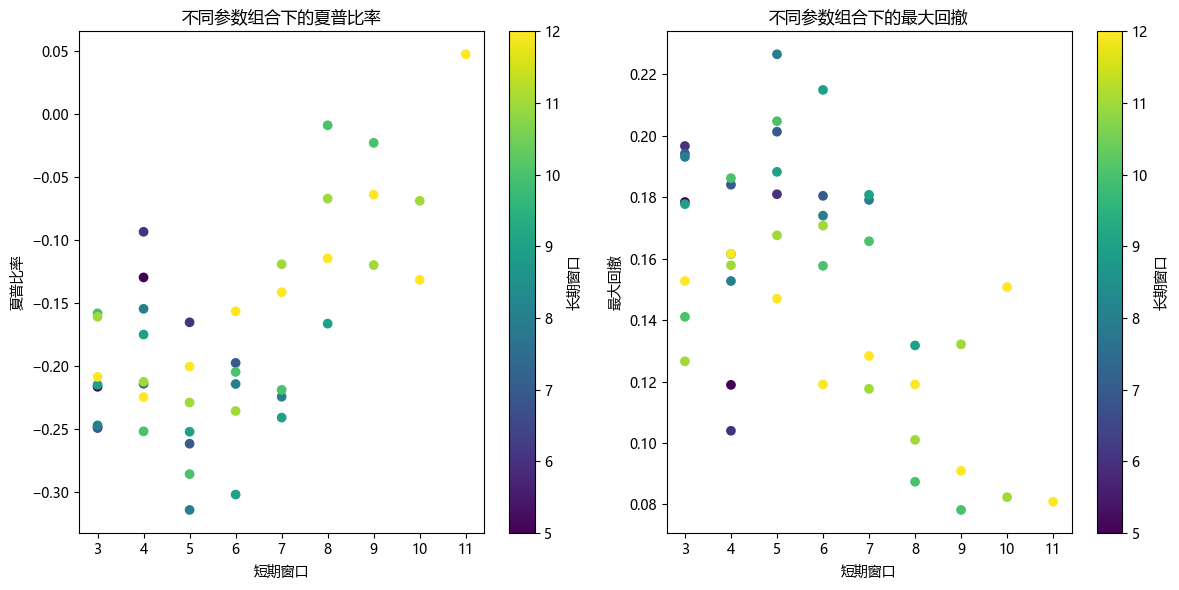

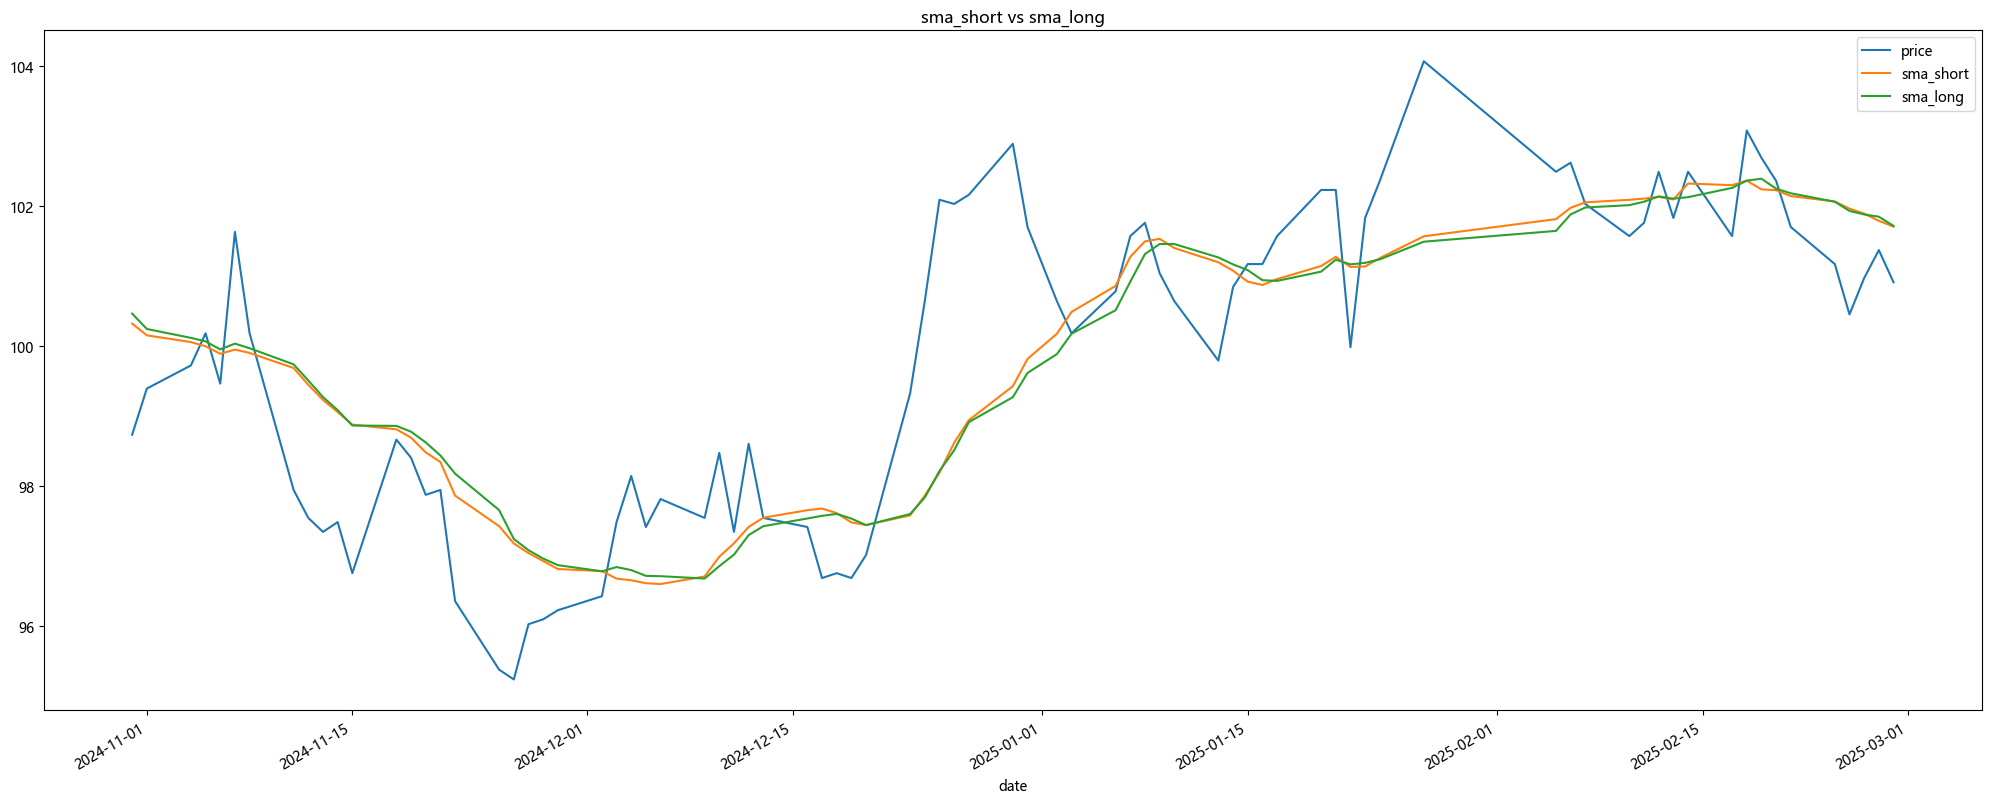

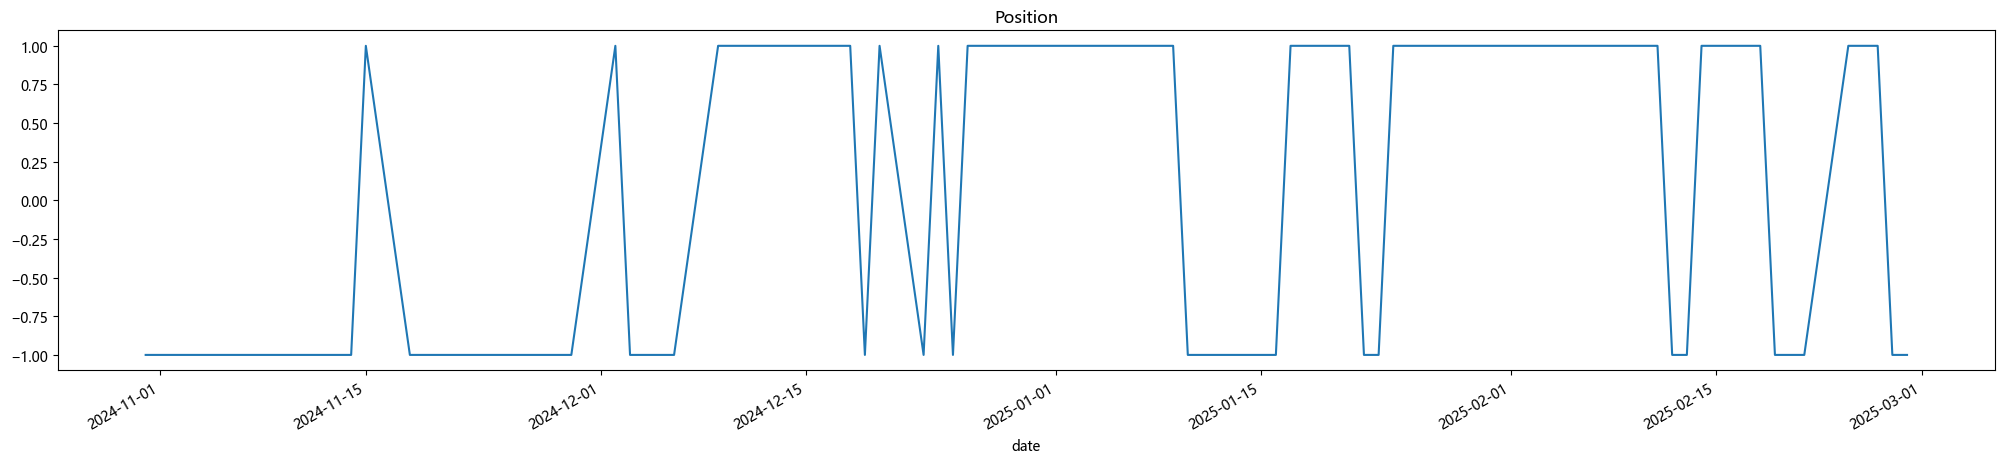

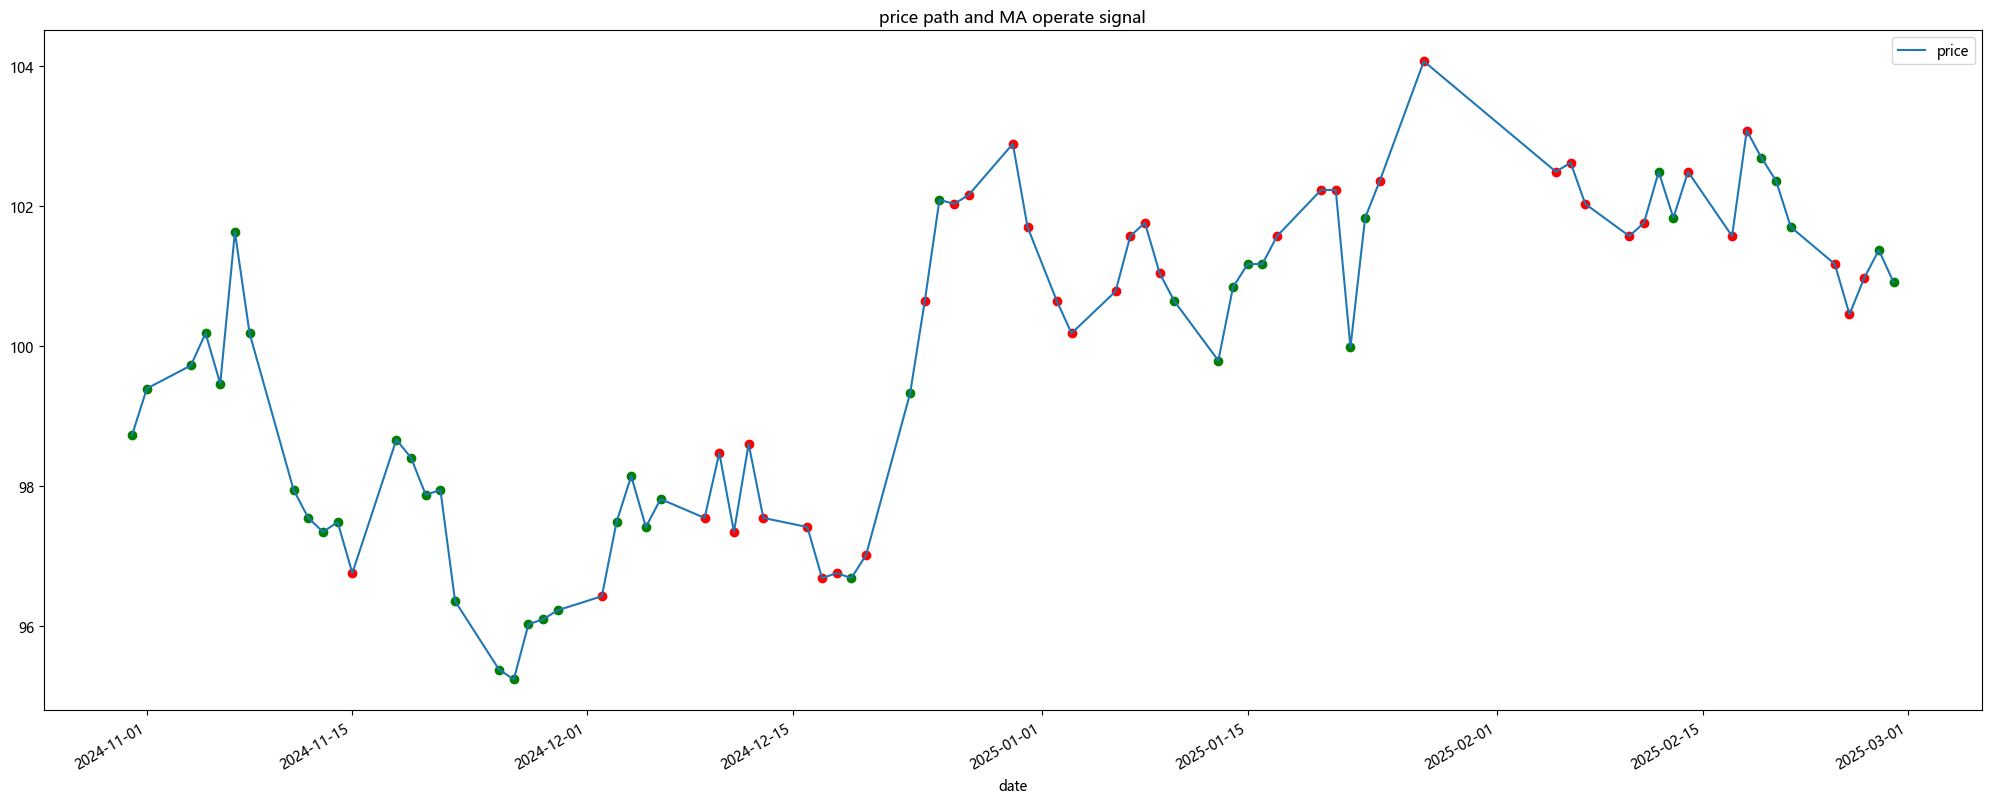

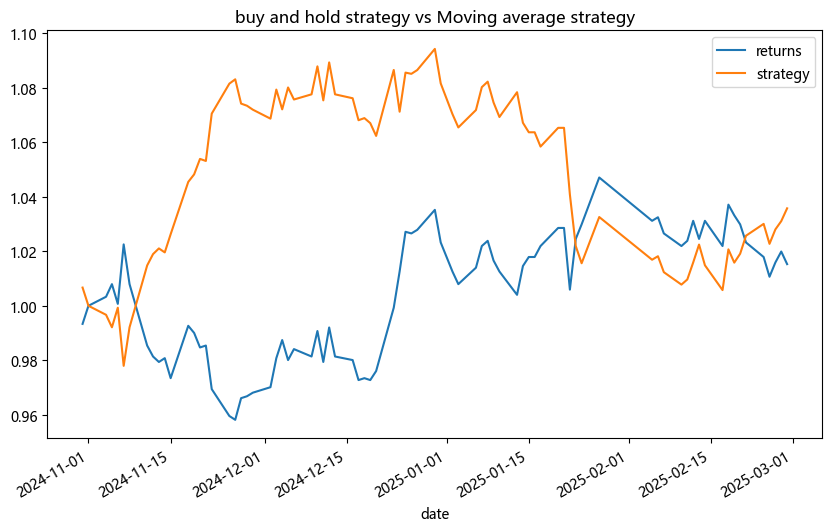

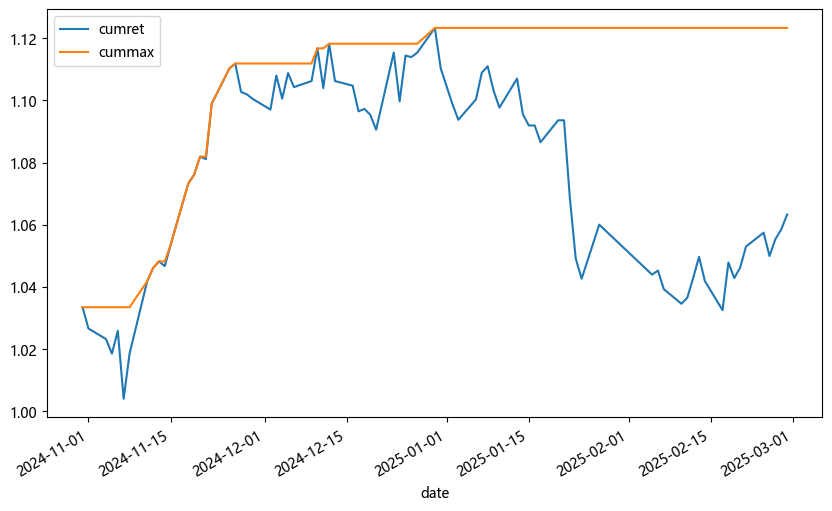

Mean Returns:
 returns     0.000190
strategy    0.000439
dtype: float64
Standard Deviations:
 returns     0.009317
strategy    0.009281
dtype: float64
Means/Standard Deviation Ratios: returns     0.020362
strategy    0.047341
dtype: float64
MA train drawdown
 0.08090039376912135
最佳动量计算窗口: 25, 最佳夏普比率: 0.0996


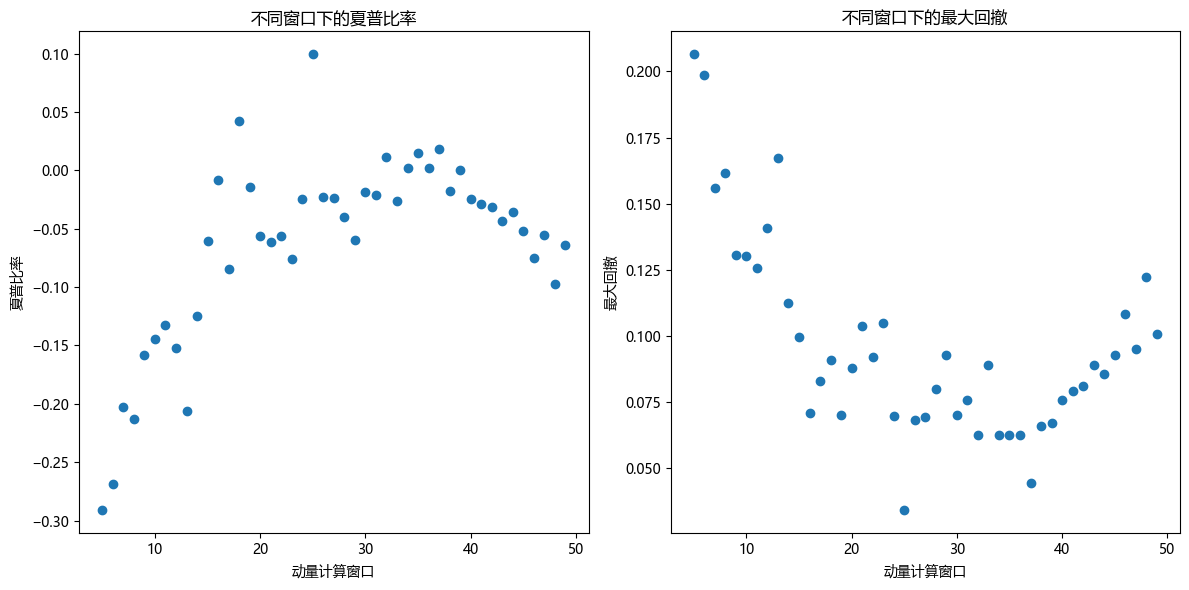

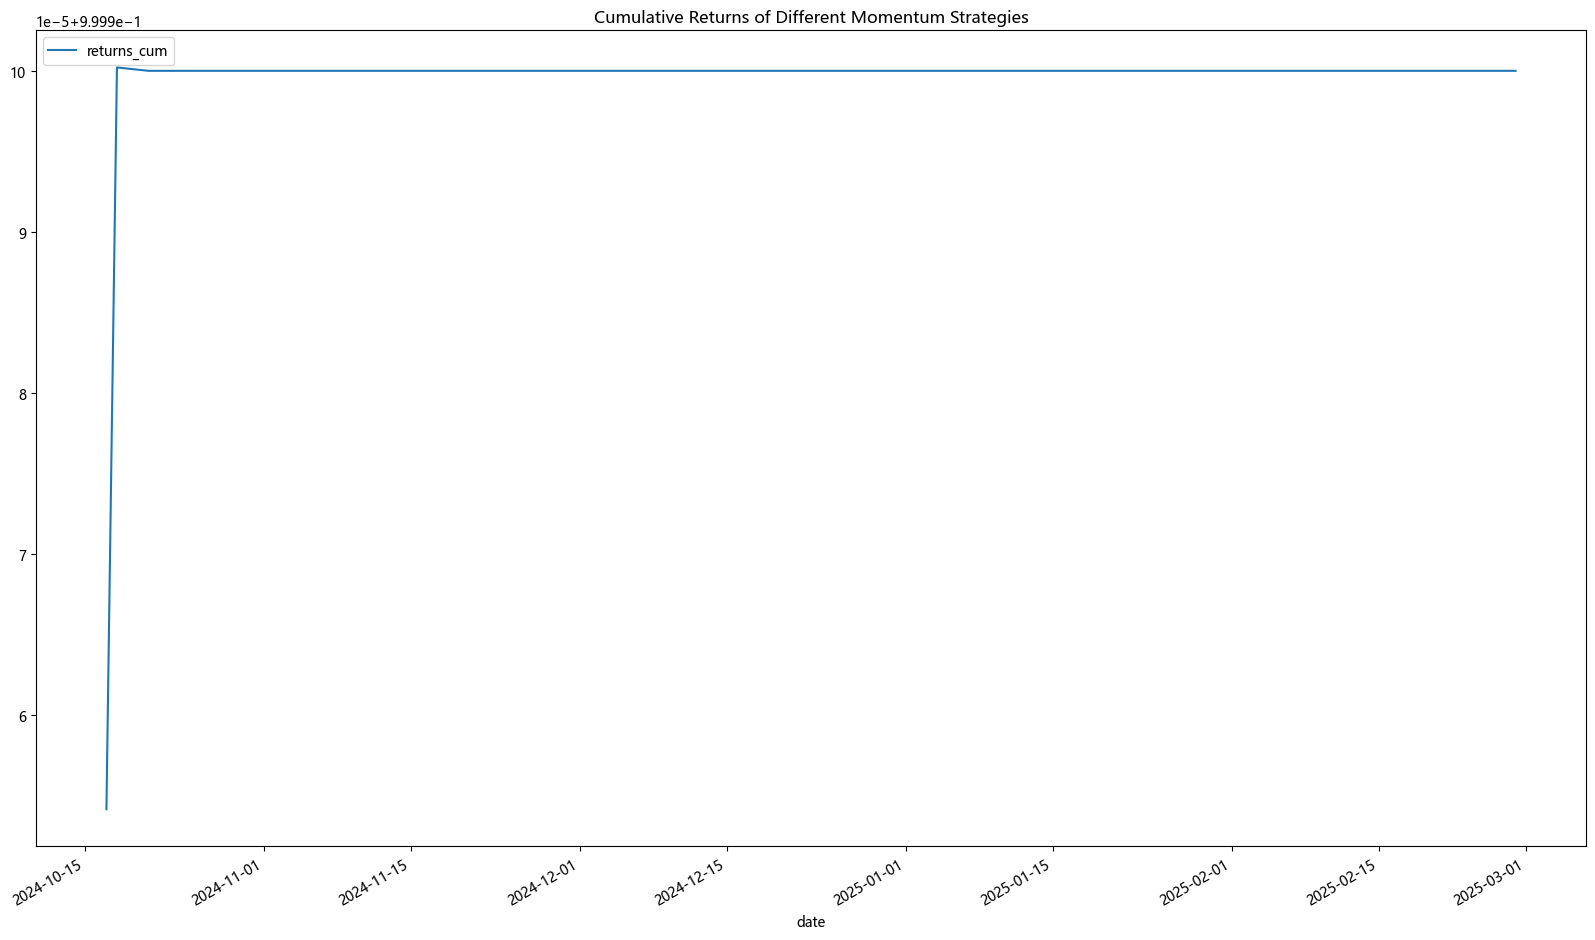

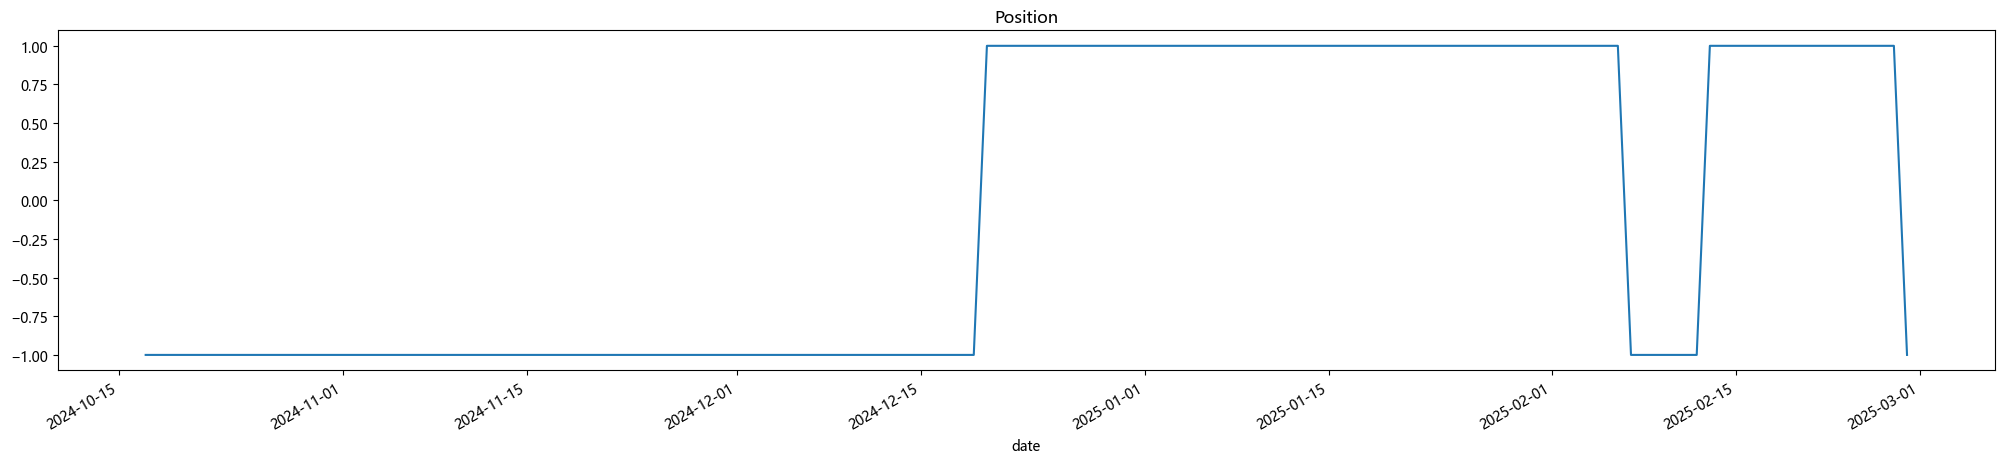

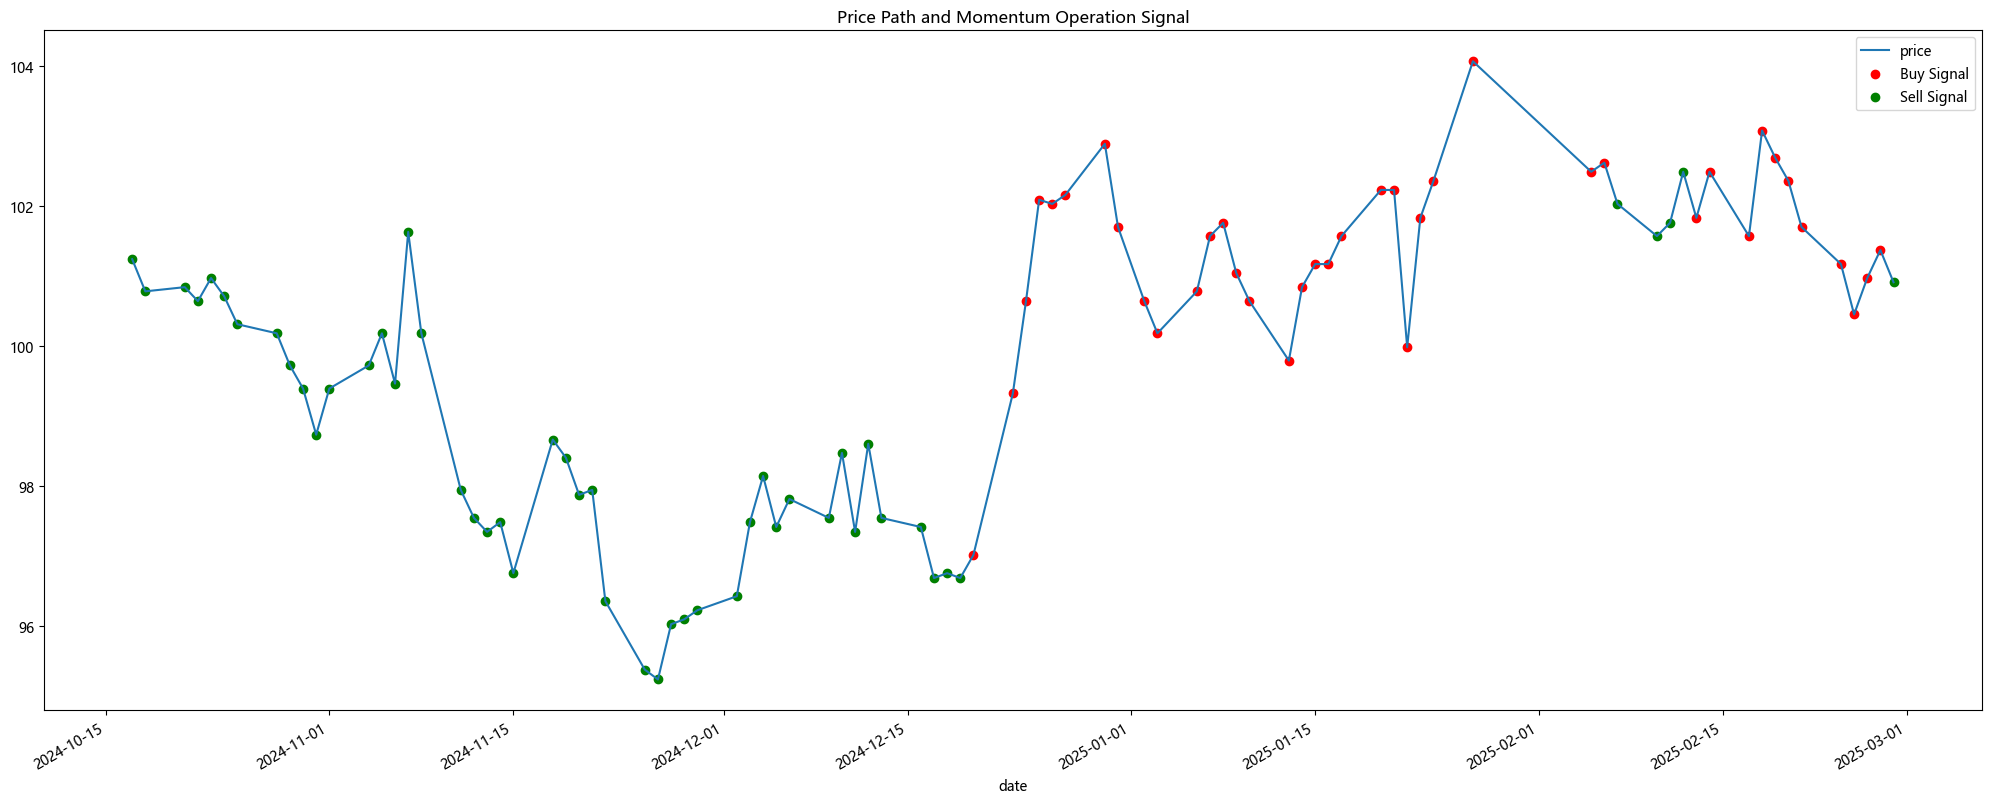

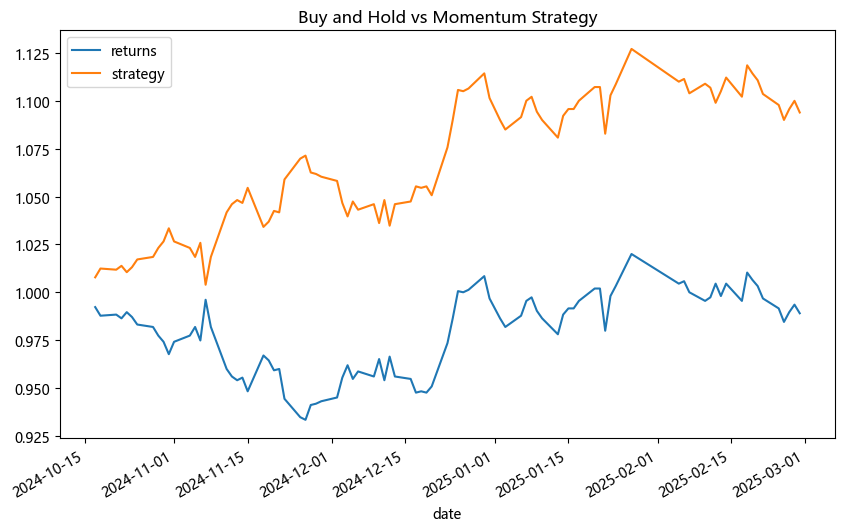

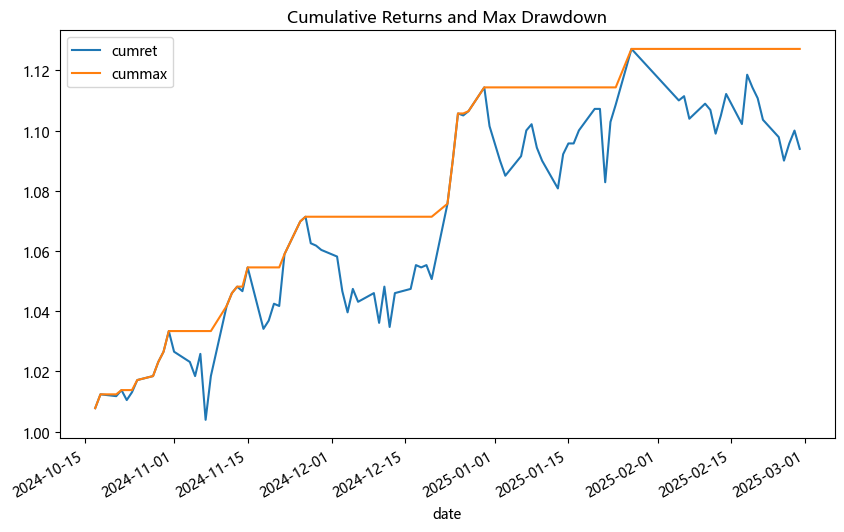

Mean Returns:
 returns    -0.000123
strategy    0.000998
dtype: float64
Standard Deviations:
 returns     0.008876
strategy    0.008832
dtype: float64
Means/Standard Deviation Ratios: returns    -0.013817
strategy    0.112963
dtype: float64
Momentum train drawdown
 0.034178498985800866


均值回归策略参数优化: 100%|██████████| 200/200 [00:01<00:00, 150.20it/s]


最佳移动平均窗口: 29, 最佳触发阈值: 1.9000000000000004, 最佳夏普比率: 0.1446


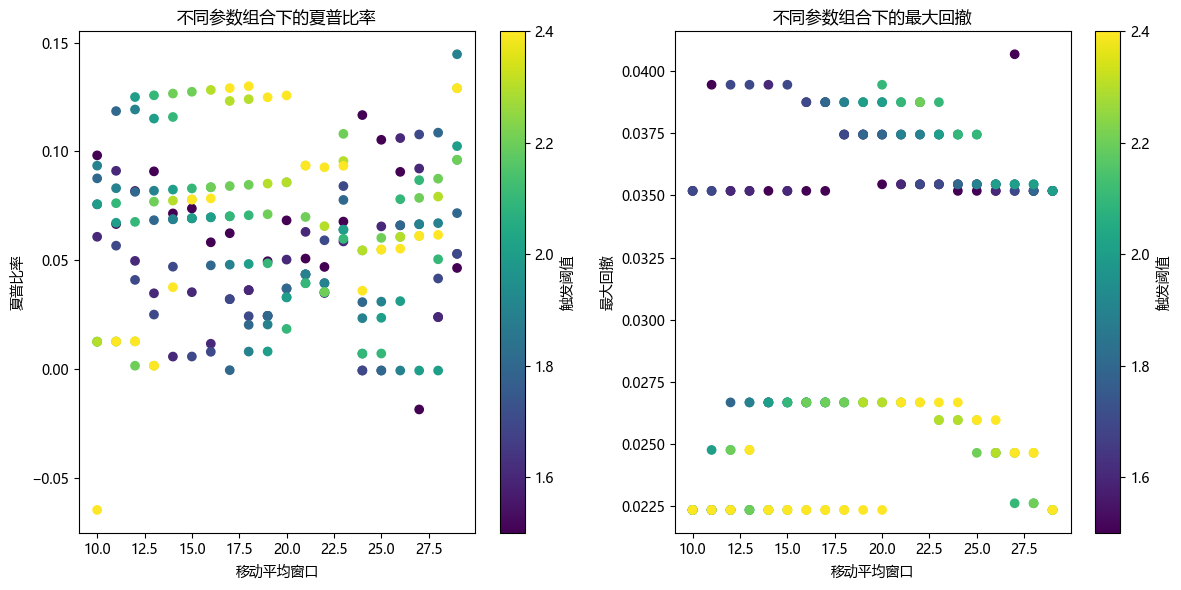

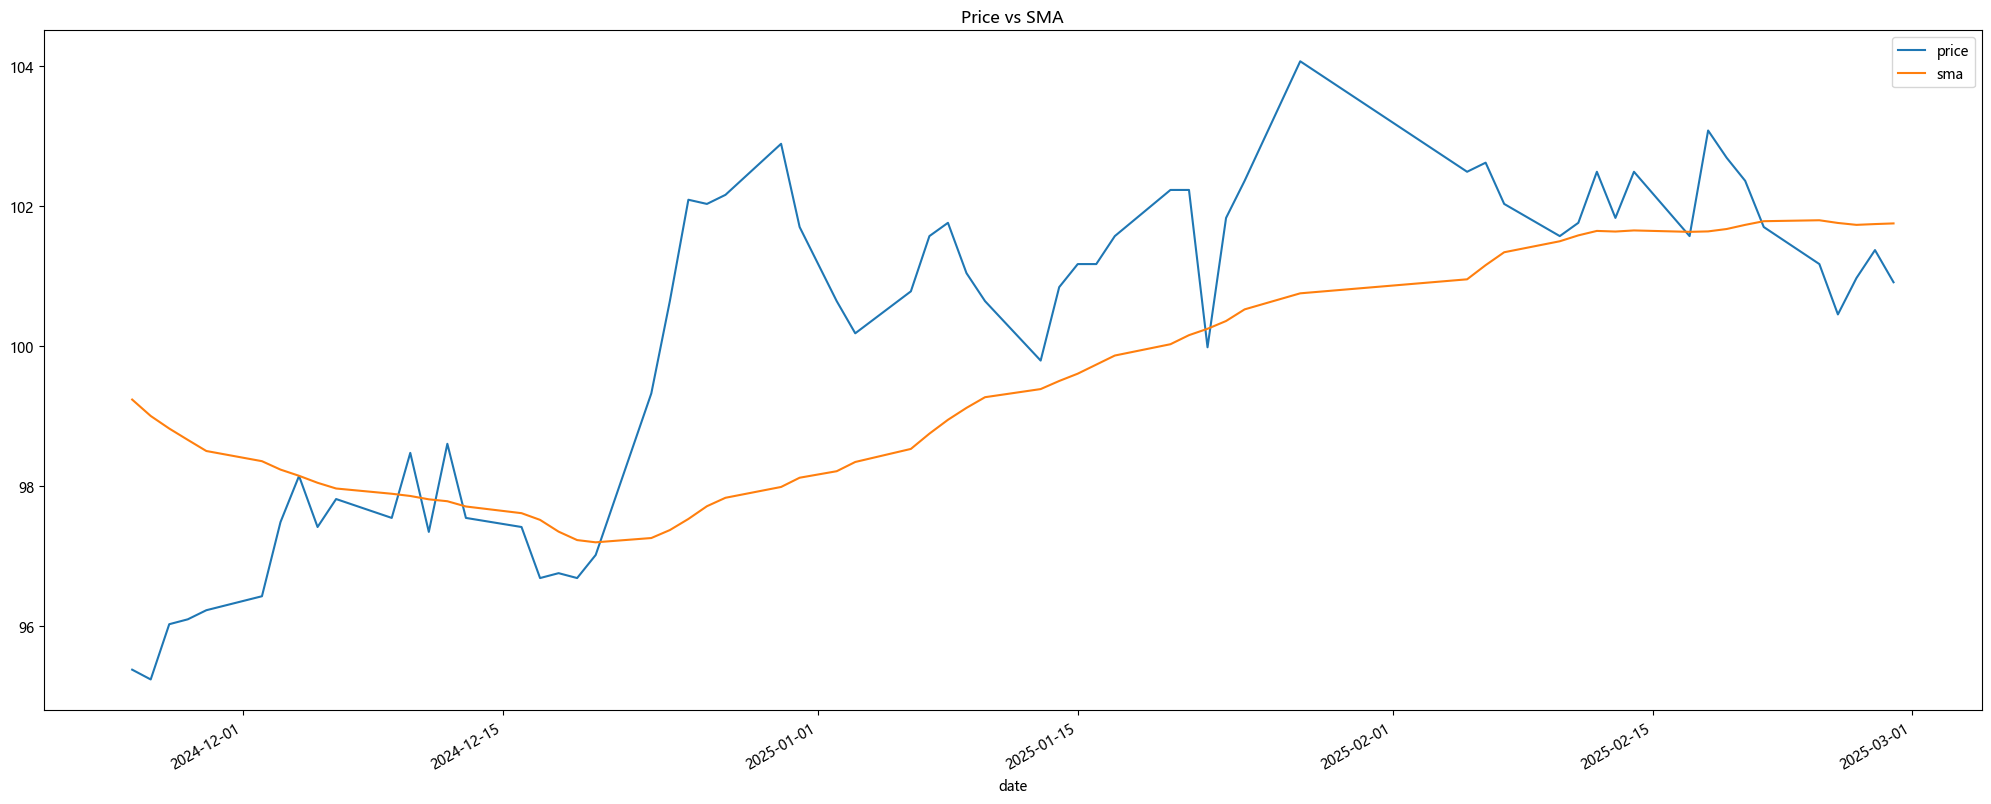

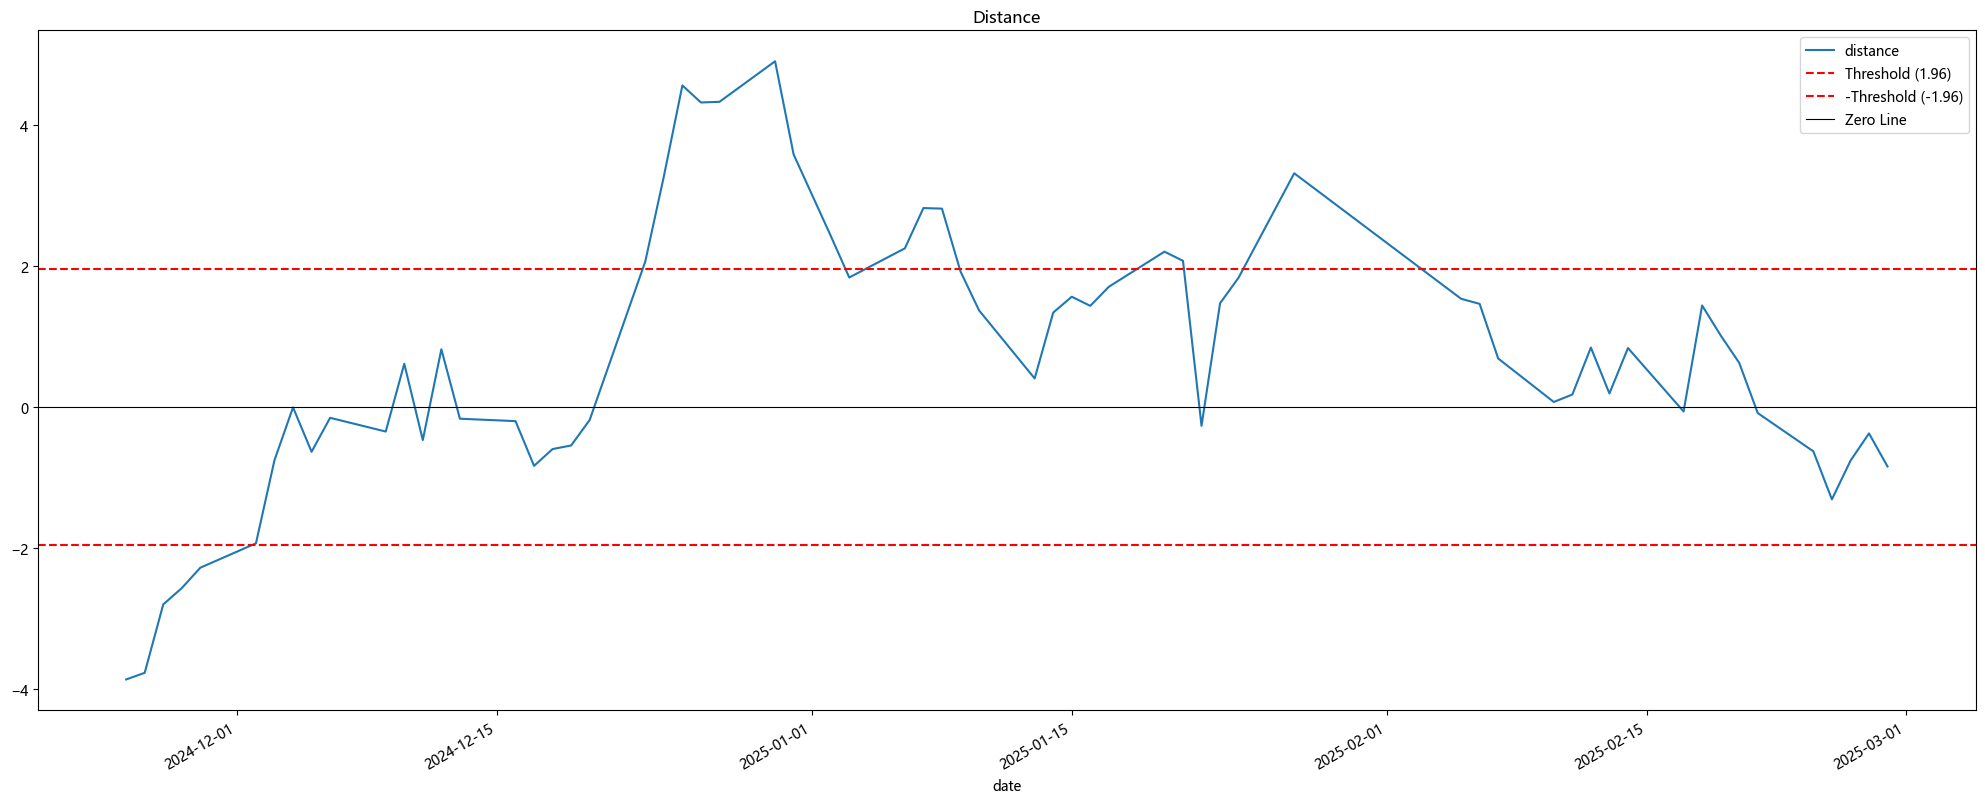

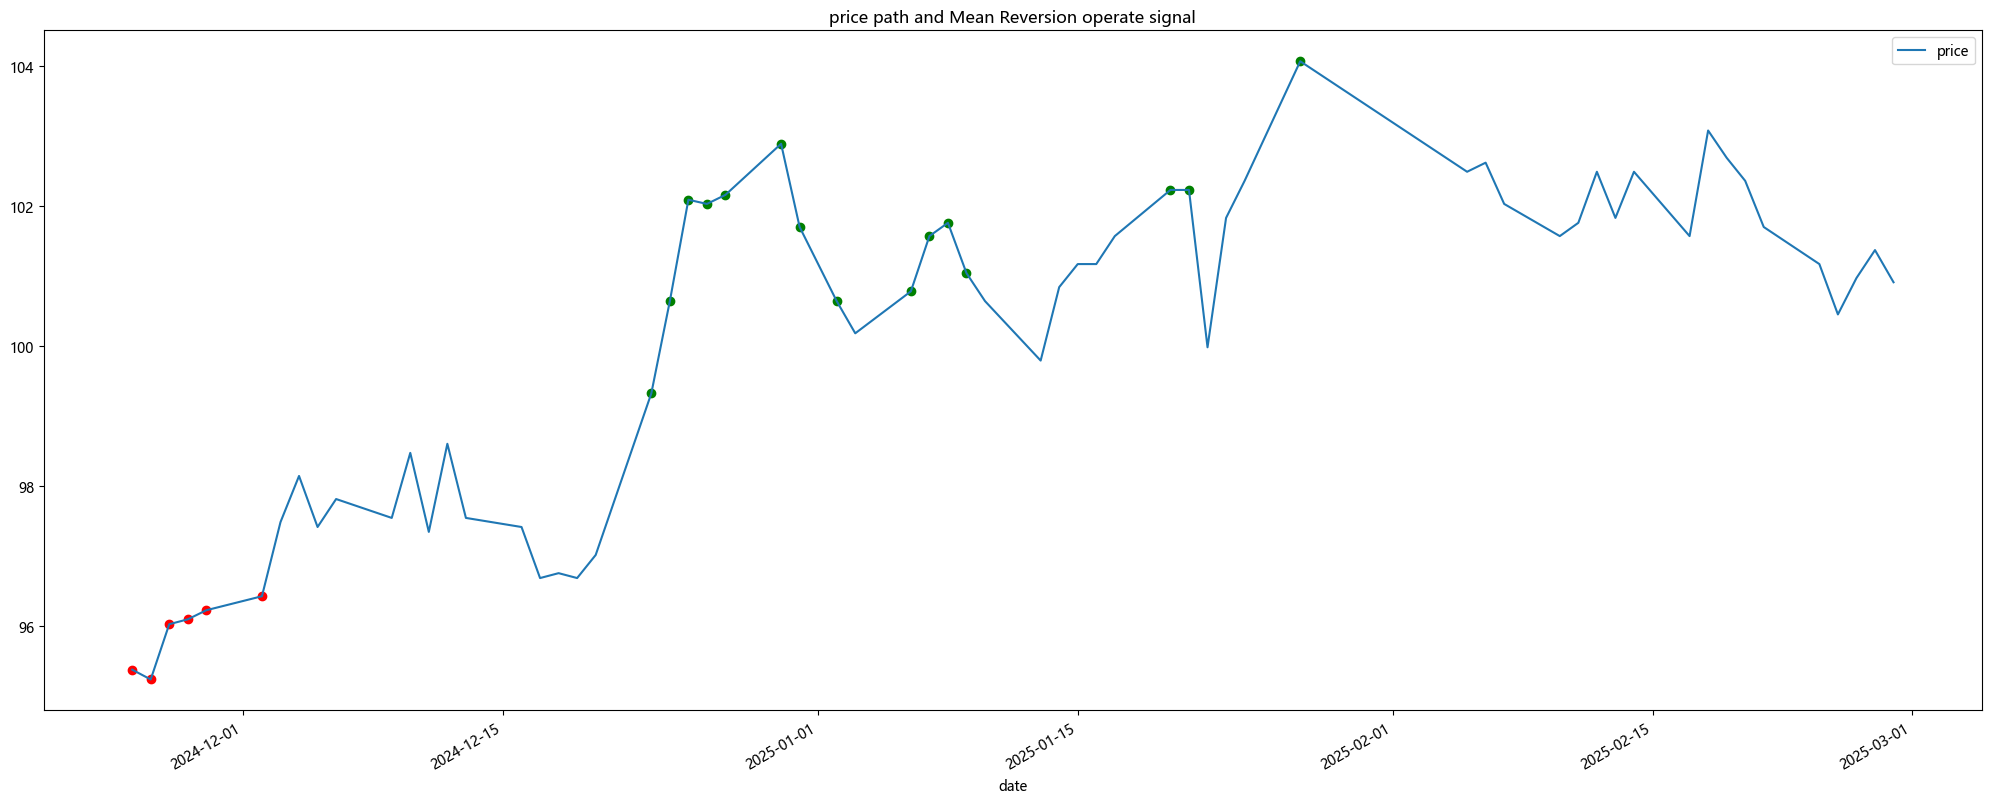

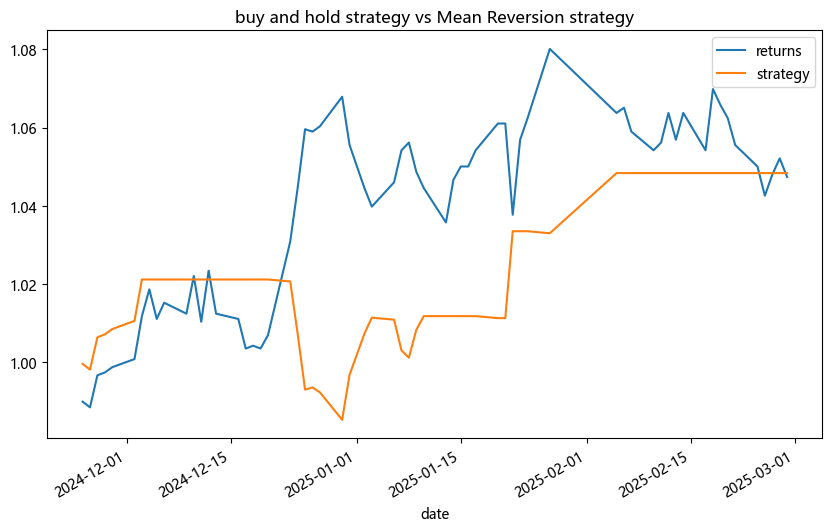

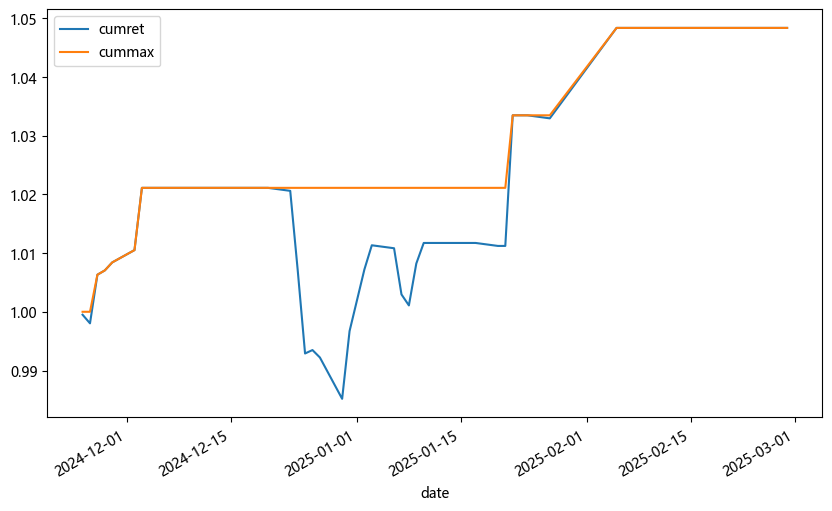

Mean Returns:
 returns     0.000734
strategy    0.000749
dtype: float64
Standard Deviations:
 returns     0.008711
strategy    0.005181
dtype: float64
Means/Standard Deviation Ratios: returns     0.084265
strategy    0.144617
dtype: float64
Mean Reversion train drawdown
 0.03517978022226569


配对交易策略参数优化:   0%|          | 0/90 [00:00<?, ?it/s]C:\Users\LM_Yuan\AppData\Local\Temp\ipykernel_5496\1297820868.py:29: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_pt['position_target'] = df_pt['position_target'].fillna(method='ffill').fillna(0)
C:\Users\LM_Yuan\AppData\Local\Temp\ipykernel_5496\1297820868.py:29: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_pt['position_target'] = df_pt['position_target'].fillna(method='ffill').fillna(0)
C:\Users\LM_Yuan\AppData\Local\Temp\ipykernel_5496\1297820868.py:29: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_pt['position_target'] = df_pt['position_target'].fillna(method='ffill').fillna(0)
C:\Users\LM_Yuan\AppData\Local\Temp\ipykernel_5496\1297820868.py:29: FutureWarning:

最佳触发阈值: 1.7000000000000002, 最佳平仓阈值: 0.1, 最佳夏普比率: 0.0643


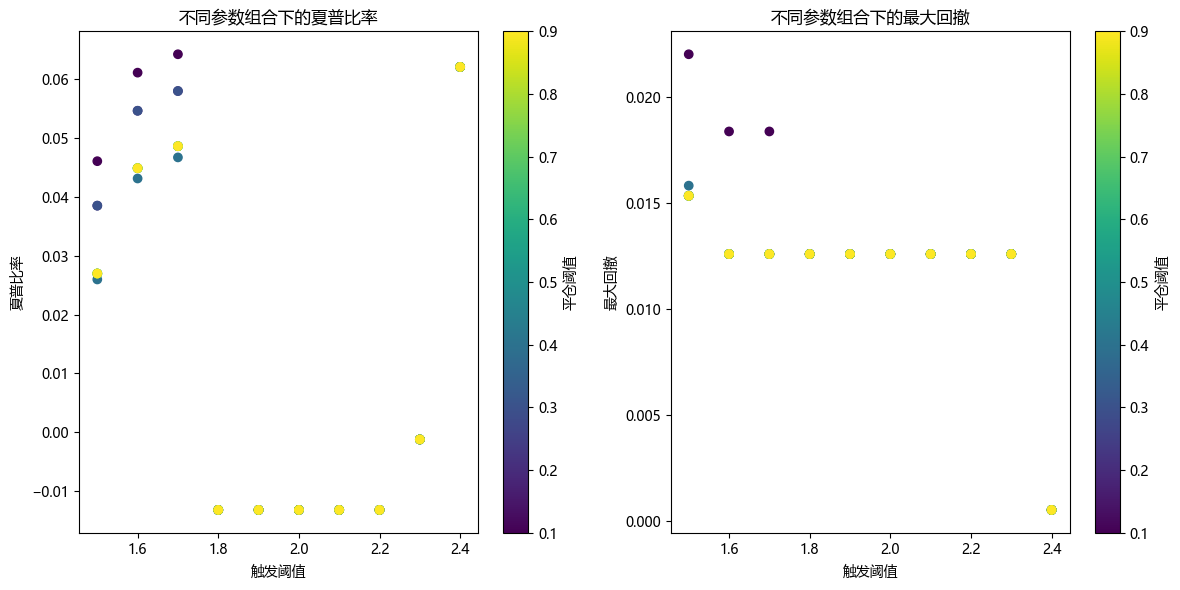

C:\Users\LM_Yuan\AppData\Local\Temp\ipykernel_5496\1297820868.py:29: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_pt['position_target'] = df_pt['position_target'].fillna(method='ffill').fillna(0)


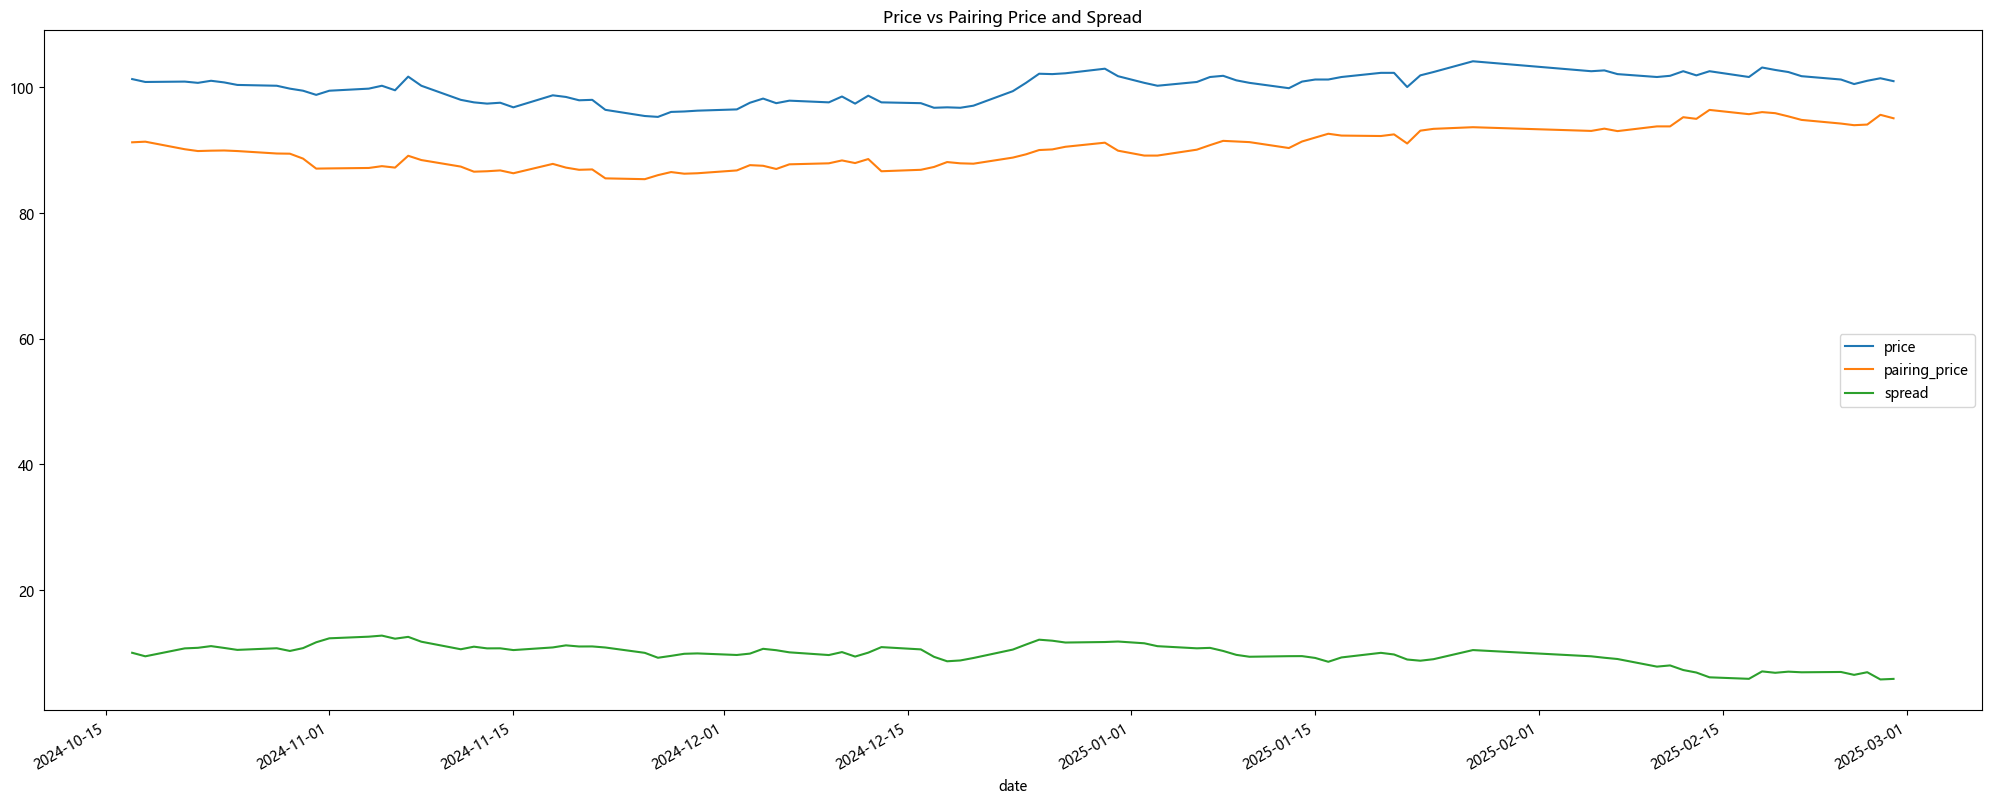

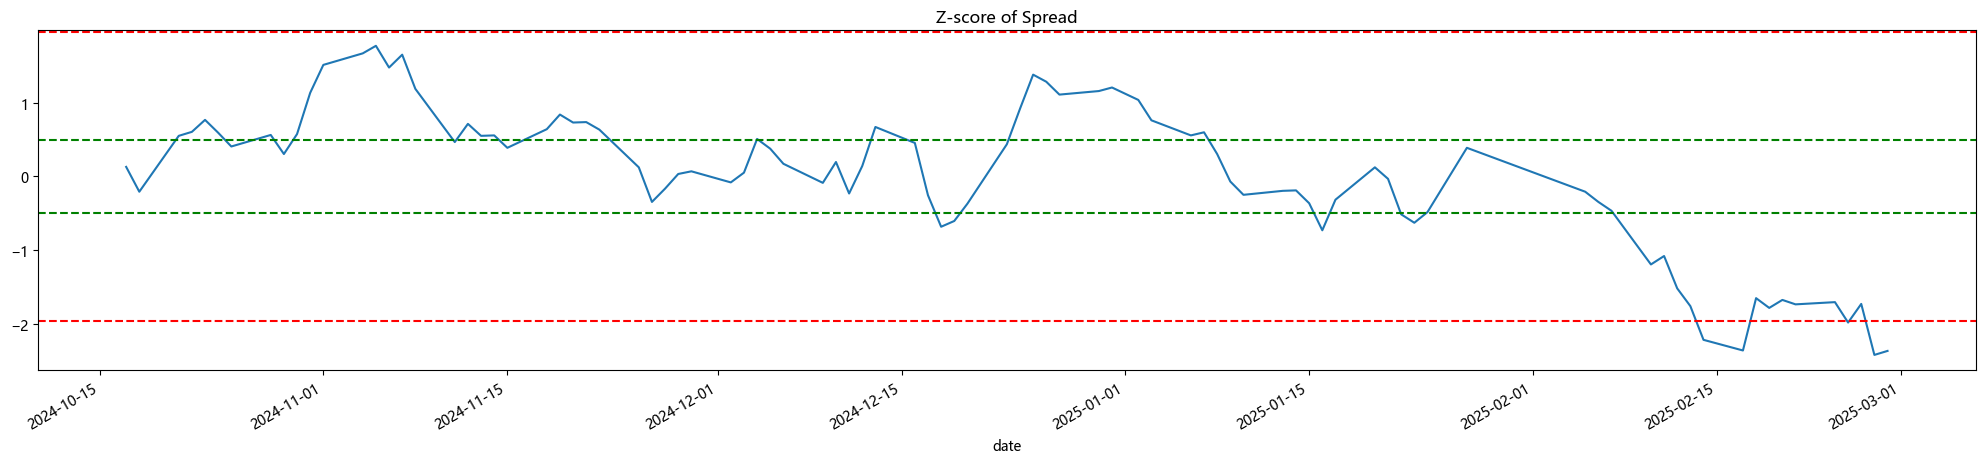

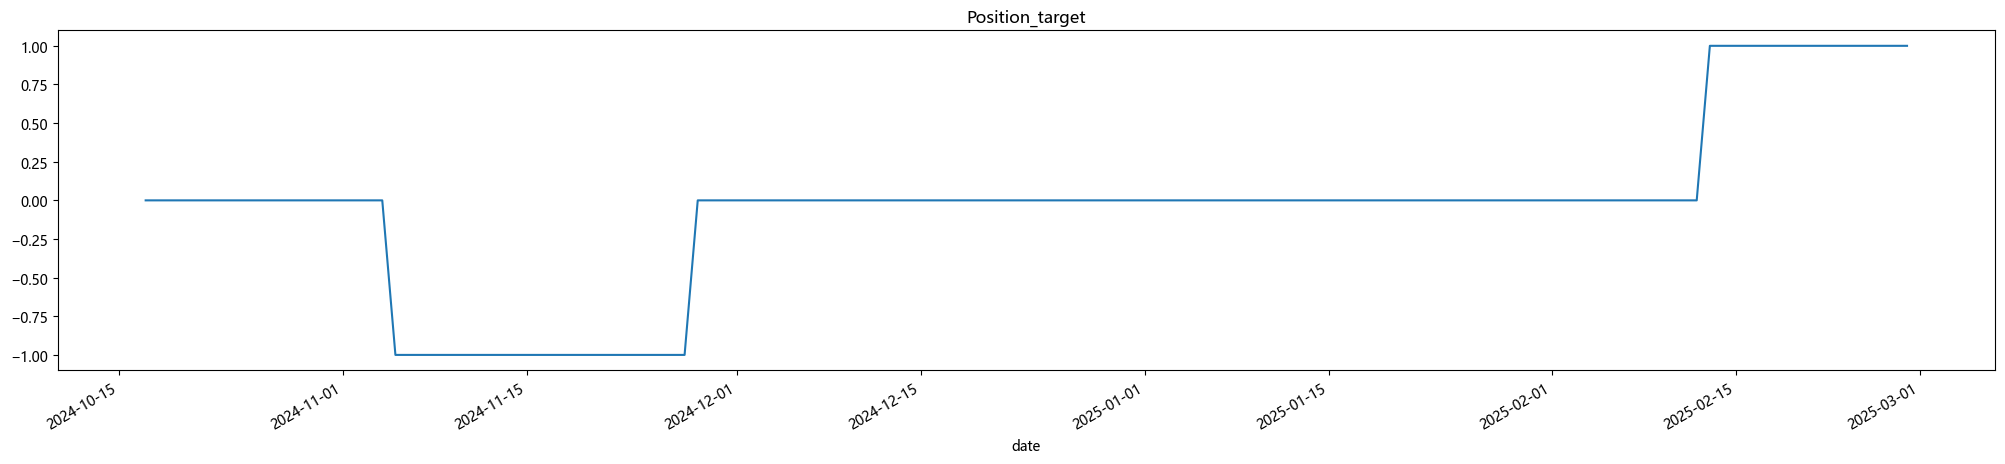

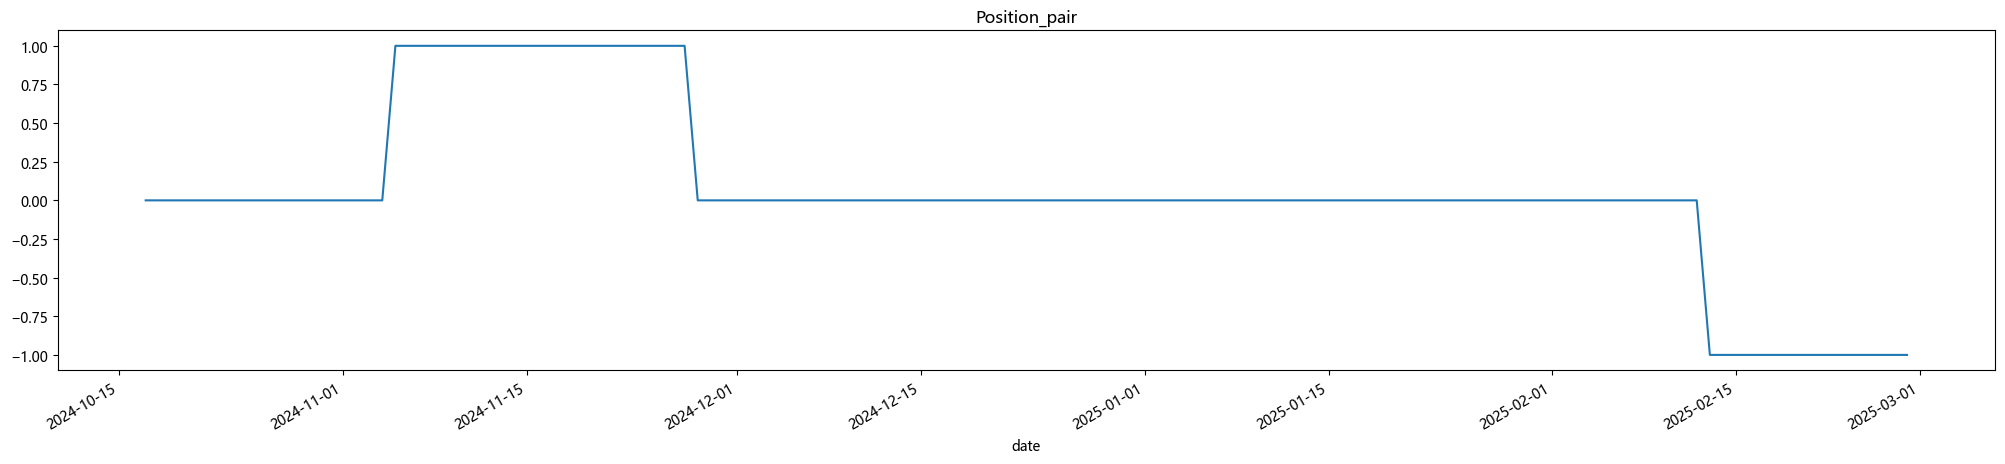

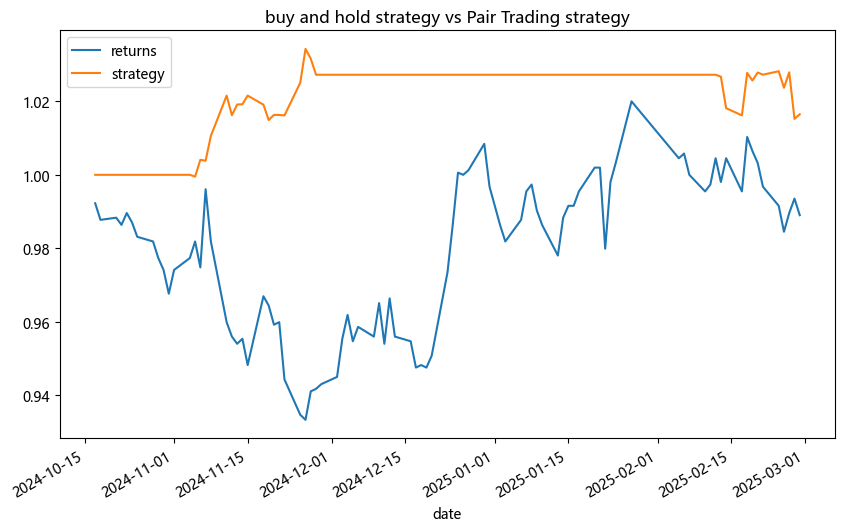

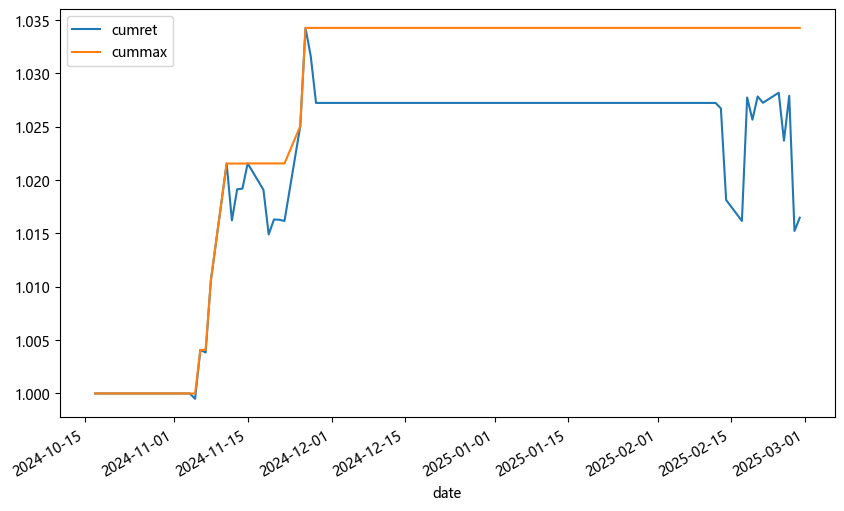

Mean Returns:
 returns    -0.000123
strategy    0.000181
dtype: float64
Standard Deviations:
 returns     0.008876
strategy    0.003051
dtype: float64
Means/Standard Deviation Ratios: returns    -0.013817
strategy    0.059489
dtype: float64
Pair Trading train drawdown
 0.018394627387934476


In [46]:
data,train,test = initialize(
    code='600000',
    pairingcode='601166',
    )

short_windows = range(3, 20)
long_windows = range(5, 13)
best_params = optimize_ma(train, short_windows, long_windows)
best_short_window, best_long_window = best_params
train_ma = ma(train, short_window=best_short_window, long_window=best_long_window)
showma(train_ma)

windows = range(5, 50)
best_param = optimize_mom(df, windows)
train_mom = mom(train, window=best_param)
showmom(train_mom)

sma_windows = range(10, 30)
thresholds = np.arange(1.5, 2.5, 0.1)
best_params = optimize_mr(train, sma_windows, thresholds)
best_sma_window, best_threshold = best_params
train_mr = mr(train, best_sma_window, best_threshold)
showmr(train_mr)

thresholds = np.arange(1.5, 2.5, 0.1)
low_zscores = np.arange(0.1, 1.0, 0.1)
best_params = optimize_pt(df, thresholds, low_zscores)
best_threshold, best_low_zscore = best_params
train_pt = pt(train, best_threshold, best_low_zscore)
showpt(train_pt)

In [47]:
# 假设权重已定义（总和建议为1）
wight1, wight2, wight3, wight4 = 0.25, 0.25, 0.25, 0.25

# 确保所有数据在同一个DataFrame中
df = train.copy()

# 检查每个数据源是否包含所需的列
required_columns = {
    'train_ma': 'position',
    'train_mom': 'position',
    'train_mr': 'position',
    'train_pt': 'position_target'  # 注意列名可能不同
}

# 将各数据源的列合并到df中
for src_name, col_name in required_columns.items():
    src_df = locals()[src_name]  # 获取对应的DataFrame（train_ma, train_mom等）
    if col_name in src_df.columns:
        df[f'{src_name}_{col_name}'] = src_df[col_name]
    else:
        raise KeyError(f"列 '{col_name}' 不在 {src_name} 中！")

# 计算加权综合position（处理可能的列名差异）
df['position'] = (
    wight1 * df['train_ma_position'] + 
    wight2 * df['train_mom_position'] + 
    wight3 * df['train_mr_position'] + 
    wight4 * df['train_pt_position_target']  # 使用实际列名
)

# 计算策略收益：前一天的position * 当天的returns
df['strategy_returns'] = df['position'].shift(1) * df['returns']

model = smf.ols(formula='strategy_returns ~ train_ma_position + train_mom_position + train_mr_position + train_pt_position_target', data=df)
results = model.fit()

In [48]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       strategy_returns   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     1.310
Date:                Thu, 24 Apr 2025   Prob (F-statistic):              0.277
Time:                        16:29:27   Log-Likelihood:                 270.71
No. Observations:                  62   AIC:                            -531.4
Df Residuals:                      57   BIC:                            -520.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [28]:
print('train_ma columns:', df.columns.tolist())
print('train_ma columns:', train_ma.columns.tolist())
print('train_mom columns:', train_mom.columns.tolist()) 
print('train_mr columns:', train_mr.columns.tolist())
print('train_pt columns:', train_pt.columns.tolist())

train_ma columns: ['price', 'volume', 'returns', 'returns_cum', 'pairing_price', 'pairing_returns', 'pairing_returns_cum', 'train_ma_position', 'train_mom_position', 'train_mr_position', 'train_pt_position_target', 'position', 'strategy_returns']
train_ma columns: ['price', 'volume', 'returns', 'returns_cum', 'pairing_price', 'pairing_returns', 'pairing_returns_cum', 'sma_short', 'sma_long', 'position', 'trade', 'strategy', 'cumret', 'cummax', 'drawdown']
train_mom columns: ['price', 'volume', 'returns', 'returns_cum', 'pairing_price', 'pairing_returns', 'pairing_returns_cum', 'position', 'trade', 'strategy', 'cumret', 'cummax', 'drawdown']
train_mr columns: ['price', 'volume', 'returns', 'returns_cum', 'pairing_price', 'pairing_returns', 'pairing_returns_cum', 'sma', 'distance', 'position', 'trade', 'strategy', 'cumret', 'cummax', 'drawdown']
train_pt columns: ['price', 'volume', 'returns', 'returns_cum', 'pairing_price', 'pairing_returns', 'pairing_returns_cum', 'spread', 'zscore', '